# 09 - Pot linearization

The position sensor in a hobby servo is a potentiometer on the output shaft. The
firmware reads it as a number from 0 to 4095 and treats that number as if it moved
in step with the shaft. On the MG90 on my bench it does not, quite. Some stretches
of the resistive track read fast and some read slow, so one count means a slightly
different angle depending on where the shaft is sitting.

The plan is simple to say. `osc` measures that once from capture data, writes a small
correction table into the servo's control table, and the firmware applies it to every
pot sample, so position and speed come out linear in the true shaft angle. Before
anybody touches firmware, this notebook builds the table from telemetry I already
have and tries to prove it with the two rules the series runs on (two independent
routes that agree, and repeats that agree). It also answers a question for notebook
08. Once the pot is linearized, is its speed good enough to fuse with the back-EMF
speed in the velocity observer?

Here is the short version, with the numbers from the cells below:

- **The error is real and sizeable.** Against the true angle the raw pot is off by
  106 counts peak to peak over the covered travel. Its local sensitivity runs from
  0.53 to 1.53 times nominal in 25-count windows and 0.71 to 1.35 in 67-count windows,
  the width of one table interval. A speed read off the raw pot is wrong by that much,
  and so is the position loop's gain.
- **Two routes agree where they both work.** Counting commutation ripple and
  integrating back-EMF give the same shape to within 1.4 counts (0.47 rms) over the
  middle of travel. At the two ends, which only rungs that are still spinning up ever
  cross, the back-EMF route reads high and the tables part by up to 11 counts. Proof
  rule 1 holds in the middle and is not met at the ends.
- **Backlash is about 1.5 ripple cycles, about 6 counts**, the same in all four
  datasets. Forward and reverse shapes are not only offset, they differ by a
  position-locked bump of up to 11 counts near raw 2500 that both routes see.
- **It repeats.** Capture to capture the shape moves 0.8 counts (sd, mean over
  travel). The slip check passes on every one of several hundred runs.
- **The 55-knot table** takes the held-out position error from 16.5 to 4.6 counts rms.
  It removes much less of the speed error, 24% to 19% at 4 ms, because a lot of the
  texture is narrower than one knot interval. A 217-knot table would get 12.6%.
- **Fusion.** Where back-EMF exists the pot should stay position only (weight about
  0.01 at 4 ms). The pot is the only speed below 14% duty and at rest, and above 50%
  duty the back-EMF model as fitted here reads 5 to 28% fast, so there a 20 ms pot
  derivative wins.
- **Downstream constants move a few percent.** $K_e$ in counts drops 3.8%, the viscous
  terms 3 to 7%, the speed-per-duty slope rises 6.5%. The soft limits sit in the
  uncorrected insets and do not move at all.

## Picking a rig

The cell below selects the primary dataset and prints what that means in hardware
terms. `mg90-a__2s` is the 2S merged session, five captures, each holding every
free-shaft procedure within a few minutes of each other on one battery. Everything
quoted as a number in this notebook comes from it. The USB datasets and the older
classic set appear only as checks, because the USB rail droops with load (notebook 00
and the supply policy of the series).

The table rails come from the session's own `envelope.toml`, which the capture tool
read off the servo. The physical stops at 209 and 3849 are the table's `raw_min` and
`raw_max`, the soft limits sit inside them and the seek guards inside those.

One constant is an input rather than an output here, the winding resistance $R$.
A free-shaft ladder cannot separate $R$ from $K_e$ because current and speed rise
together, so I pin it from the onset regression in the bringup repo and show what its
bracket does to every result that uses it.

In [1]:
import tomllib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import potlut, ripple, session

# 2S is the primary dataset. The USB rail droops with load, so USB numbers are a
# direction check only and never land in a constant (supply policy).
ds = oscnb.use("mg90-a__2s")
board, servo = oscnb.current().board, oscnb.current().servo

# The session's own envelope, written by the capture pilot from the servo's
# control table: physical stops, soft limits and seek guards, all in raw counts.
env = tomllib.loads((ds.path / "envelope.toml").read_text())
RAW_MIN, RAW_MAX = env["limits"]["phys"]   # the LUT's rails: the hand stops
SOFT = tuple(env["limits"]["soft"])          # soft limits the firmware clamps goals to
GUARD = tuple(env["limits"]["guard"])        # seek guards, the ends of every rung

FS = board.tick_hz                           # telemetry samples per second
DT = 1.0 / FS                                # seconds per sample
Q15 = 32767                                  # duty full scale on the wire
R_OHM = servo.measured["r_winding_measured"].value   # winding resistance, pinned (section 3)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.DataFrame([
    ("LUT rails (physical stops)", f"{RAW_MIN} .. {RAW_MAX}", "raw counts", "envelope.toml limits.phys"),
    ("soft limits", f"{SOFT[0]} .. {SOFT[1]}", "raw counts", "envelope.toml limits.soft"),
    ("seek guards", f"{GUARD[0]} .. {GUARD[1]}", "raw counts", "envelope.toml limits.guard"),
    ("knot spacing", f"{(RAW_MAX - RAW_MIN) / (potlut.N_KNOTS - 1):.2f}", "raw counts", "55 knots over the rails"),
    ("winding resistance R", f"{R_OHM:g}", "ohm", servo.measured["r_winding_measured"].source),
], columns=["quantity", "value", "unit", "source"]).set_index("quantity")

dataset  mg90-a__2s
supply   2s
rig      Vorpal MG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
session,5,2,"fast, slow"



derived constants (what the hardware is)


value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   3.0606
                 terminal difference                                mV per count            2.4658
                 terminal bias VB                                   mV                    627.9352
                                                                    counts                779.4008
                 driven-low terminal reads                          counts                524.7451
                 motor current                                      mA per count            0.8952
                                                                    counts per A         1117.0909
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      15.0000
                 rail tap ratio                                                             2.5000
                 sample rate                                        samples per ms         20.0000
                 current settled from (UNVERIFIED)                  % duty                 13.3333
                 voltage settled from (UNVERIFIED)                  % duty                 13.3333
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      20.0000
                 envelope low                                       counts (15.55 deg)    520.0000
                 envelope high                                      counts (166.55 deg)  3540.0000
                 runway                                             counts               3020.0000
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800


measured values (what someone found when they looked)


value                  unit         bracket  \
where quantity                                                             
board vb_bias              781.000                counts      [775, 783]   
      rail_droop_usb        -3.500   % over 20-100% duty        [-4, -3]   
      opa_noise_floor        2.200            counts RMS        [2, 2.4]   
      esd_clamp_skew         1.800                V bemf      [1.7, 1.9]   
      vdd                    3.280                     V    [3.27, 3.29]   
      terminal_chain         0.000              % vs DMM     [-0.7, 0.7]   
      current_chain_scale    1.200  % high vs grid route     [-1.5, 3.9]   
      crest_floor           15.000          % duty on 2S        [15, 17]   
servo r_winding              4.890                   Ohm    [4.49, 4.98]   
      ke_ripple              1.295      mV per ripple Hz  [1.284, 1.306]   
      backlash               1.480         ripple cycles     [1.25, 1.5]   

                                                                      source  \
where quantity                                                                 
board vb_bias                        Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                         2S vs USB grid, 5 captures each   
      opa_noise_floor                                bringup isns-diff run29   
      esd_clamp_skew                              bringup isns-diff findings   
      vdd                           nb00 sec 10.1, DMM at the 3V3 test point   
      terminal_chain                        nb00 sec 10.2, 4x4 grid at 1.7 A   
      current_chain_scale                          nb00 sec 10.3, 2S DC laps   
      crest_floor           nb00 sec 10.5-10.6, static-load ladders + bursts   
servo r_winding            bringup captures/mg90/plant.py, onset regressi...   
      ke_ripple            nb09 sec 3, settled windows of the 15-50% grid...   
      backlash             nb09 sec 4, reversal blocks, commutation steps...   

                                                                      caveat  
where quantity                                                                
board vb_bias              nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb       USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor      arm-B external network at G15; the internal PG...  
      esd_clamp_skew       above this the A-side ESD clamp skews the divi...  
      vdd                  vdd_mv stays 3300 so the sense block every cap...  
      terminal_chain       both directions inside the meter's band or wit...  
      current_chain_scale  no gross scale error; the bracket is the grid'...  
      crest_floor          honest crest current from 15% on 2S (amplifier...  
servo r_winding            value and upper bracket from the onset route (...  
      ke_ripple            forward 1.306, reverse 1.284, fitted per direc...  
      backlash             about 5.7 raw counts at the mean coupling. Bra...

,value,unit,source
quantity,,,
LUT rails (physical stops),209 .. 3849,raw counts,envelope.toml limits.phys
soft limits,432 .. 3626,raw counts,envelope.toml limits.soft
seek guards,532 .. 3526,raw counts,envelope.toml limits.guard
knot spacing,67.41,raw counts,55 knots over the rails
winding resistance R,4.89,ohm,"bringup captures/mg90/plant.py, onset regressi..."


## The data, and the tracker

Every capture holds a duty grid, 5 to 100% in 5% steps, forward then reverse. Each
**rung** is one constant-duty burst that starts at a seek guard and runs about 2600
counts toward the other end. Those rungs are the whole diet of this notebook.

The motor-side angle comes from the **commutation ripple**. Each time a brush crosses
a gap in the commutator the winding current steps, six times per motor revolution on
this 3-slot motor, and the 20 kHz current stream shows that as a clean spectral line.
Counting its cycles gives the motor angle in ripple cycles, with no pot involved at
all. The tracker is `oscnb.ripple.motor_angle` from notebook 06. I work in ripple
cycles and pot counts everywhere and never convert to degrees. The gear ratio of this
servo is not known yet, and deriving it from ripple against pot would fold the very
pot error this notebook measures into it.

The tracker seeds its search from the pot speed times a **coupling prior** (cycles per
count), within plus or minus 30%. That is a place where the pot's own error could bite,
so the first cell measures the prior from settled 20 to 40% rungs and the next one
checks how far the seed actually landed from the line the tracker followed.

In [2]:
# The other datasets, each read under the board its own recordings name.
ds_usb = oscnb.datasets.load("mg90-a__usb")                   # session, USB, same firmware as the 2S session
ds_usb_old = oscnb.datasets.load("mg90-a__dev-v006-D__usb")   # the first session set, USB, a day earlier
ds_classic = oscnb.datasets.load("mg90-a__dev-v006-D__2s")    # classic experiments, 2S, a day earlier

def complete(d):
    # A session capture counts only when both recordings landed. The USB set was
    # still recording when this notebook ran, so its last capture can be partial.
    return [c for c in d.captures("session")
            if {r.name for r in d.recordings("session", c)} >= {"slow", "fast"}]

def frames(d, view):
    # (capture, frame, meta) for every usable capture. A session dataset is sliced
    # into the named view, a classic one reads the experiment of that name.
    if "session" in d.experiments:
        for c in complete(d):
            df, meta = session.read(d, c, view)
            yield c, df, meta
    else:
        for c in d.captures(view):
            recs = d.recordings(view, c)
            if len(recs) == 1:                 # skips an empty capture folder
                yield c, recs[0].frame(), recs[0].meta

pd.DataFrame([
    {"dataset": d.key, "supply": d.supply, "board": d.board.key,
     "grid captures": len(list(complete(d))) if "session" in d.experiments else len(d.captures("grid"))}
    for d in (ds, ds_usb, ds_usb_old, ds_classic)
]).set_index("dataset")

,supply,board,grid captures
dataset,,,
mg90-a__2s,2s,dev-v006-D,5
mg90-a__usb,usb,dev-v006-D,5
mg90-a__dev-v006-D__usb,usb,dev-v006-D,5
mg90-a__dev-v006-D__2s,2s,dev-v006-D,10


In [3]:
# A first coupling estimate, only to seed the tracker off the sub-line family.
# Settled window of the 20 to 40% grid rungs: line frequency over pot speed.
rows = []
for cap, df, meta in frames(ds, "grid"):
    bias = df[df.seg == 0].current_raw.mean()           # the amplifier offset of this recording
    for seg, g in df[df.seg > 0].groupby("seg"):
        duty = g.cmd_duty_q15.iloc[0] * 100 / Q15
        if not 20 <= abs(duty) <= 40:
            continue
        st = ripple.settled(g)                           # last 60% of the rung
        f, X = ripple.line_spectrum(st.current_raw.to_numpy() - bias, FS)
        fr, _ = ripple.settled_line(f, X)                # the line, promoted off a sub-line if needed
        v = abs(ripple.pot_speed(st, FS, 1.0))           # pot counts per second, least squares
        rows.append({"cap": cap, "duty": round(duty), "f_line_Hz": fr, "pot_cps": v, "cyc_per_count": fr / v})
prior = pd.DataFrame(rows)
C_PRIOR = prior["cyc_per_count"].median()                # ripple cycles per raw pot count
print(f"coupling prior {C_PRIOR:.4f} cycles per count, spread over {len(prior)} rungs "
      f"{prior.cyc_per_count.min():.4f} .. {prior.cyc_per_count.max():.4f}")

coupling prior 0.2709 cycles per count, spread over 40 rungs 0.2649 .. 0.2753


In [4]:
MIN_ACCEPT = 0.90     # a rung counts only if the tracker holds the line over 90% of it
CPC_TOL = 0.03        # and its whole-rung coupling sits within 3% of its set's median

def track(d, view, label):
    # Every drive rung of a view through the ripple tracker. Returns one dict per
    # rung carrying the arrays later sections need, with the motor angle in ripple
    # cycles, unsigned and rising, at every sample.
    out = []
    for cap, df, meta in frames(d, view):
        bias = df[df.seg == 0].current_raw.mean()
        df = df.assign(bias=bias)                                     # motor_angle reads it per rung
        for seg, g in df[df.seg > 0].groupby("seg"):
            duty = g.cmd_duty_q15.iloc[0] * 100 / Q15
            if abs(duty) < 12 or g.cmd_duty_q15.nunique() > 1:      # below the tracker floor, or a chained flip
                continue
            r = {"set": label, "cap": cap, "seg": int(seg), "duty": int(round(duty)), "n": len(g),
                 "pos": g.pos.to_numpy(), "cur": g.current_raw.to_numpy() - bias,
                 "va": g.vmotor_a.to_numpy(), "vb": g.vmotor_b.to_numpy(),
                 "dq": g.duty_q15.to_numpy(), "valid": g.window_valid.to_numpy()}
            cyc, n0, ridge = ripple.motor_angle(g, C_PRIOR, FS, 1.0)
            if cyc is None:
                r.update(ok=False, accept=0.0)
                out.append(r)
                continue
            st = ripple.settled(g)
            v = abs(ripple.pot_speed(st, FS, 1.0))
            p = r["pos"]
            r.update(cyc=cyc, n0=n0, accept=(len(g) - n0) / len(g),
                     cpc=(cyc[-1] - cyc[n0]) / abs(p[-1] - p[n0]) if p[-1] != p[n0] else np.nan,
                     # where the seed band was centred against where the ridge actually ended
                     seed_ratio=ridge["f"].iloc[-1] / (C_PRIOR * v),
                     lo=int(p[n0:].min()), hi=int(p[n0:].max()))
            out.append(r)
    # acceptance: enough of the rung tracked, and a coupling that is not a family member
    tracked = [r for r in out if "cyc" in r]
    med = np.median([r["cpc"] for r in tracked if 15 <= abs(r["duty"]) <= 50])
    for r in out:
        r["ok"] = "cyc" in r and r["accept"] >= MIN_ACCEPT and abs(r["cpc"] / med - 1) < CPC_TOL
    return out

rungs = {
    "2S session": track(ds, "grid", "2S session"),
    "USB session": track(ds_usb, "grid", "USB session"),
    "USB session, first set": track(ds_usb_old, "grid", "USB session, first set"),
    "2S classic grid": track(ds_classic, "grid", "2S classic grid"),
    "2S classic steady steps": track(ds_classic, "ripple", "2S classic steady steps"),
}

def summary(rs):
    t = pd.DataFrame([{k: r.get(k) for k in ("set", "cap", "duty", "ok", "accept", "cpc", "seed_ratio")} for r in rs])
    t["band"] = pd.cut(t.duty.abs(), [0, 14, 50, 100], labels=["12-14%", "15-50%", "55-100%"])
    t["dir"] = np.where(t.duty > 0, "fwd", "rev")
    return t

tab = pd.concat([summary(rs) for rs in rungs.values()])
tab.groupby(["set", "band", "dir"], observed=True).agg(
    rungs=("ok", "size"), accepted=("ok", "sum"),
    tracked_fraction=("accept", "mean"),
    cycles_per_count=("cpc", "median"),
    seed_ratio_min=("seed_ratio", "min"), seed_ratio_max=("seed_ratio", "max")).round(4)

rungs  accepted  tracked_fraction  cycles_per_count  seed_ratio_min  seed_ratio_max
set                     band    dir                                                                                     
2S classic grid         15-50%  fwd     80        80            0.9707            0.2649          0.9905          1.0050
                                rev     80        80            0.9737            0.2629          0.9974          1.0190
                        55-100% fwd    100        11            0.5773            0.2688          0.8360          1.0499
                                rev    100        98            0.9395            0.2630          0.9934          1.0383
2S classic steady steps 15-50%  fwd     10        10            0.9688            0.2663          1.0223          1.0346
                                rev     10        10            0.9674            0.2565          0.9924          1.0081
                        55-100% fwd      5         0            0.3287            0.2631          0.8671          1.0321
                                rev      5         4            0.9111            0.2573          0.9919          0.9994
2S session              15-50%  fwd     40        40            0.9742            0.2614          0.9645          1.0004
                                rev     40        39            0.9688            0.2629          0.9737          1.0293
                        55-100% fwd     50        10            0.7903            0.2681          0.8233          1.0199
                                rev     50        45            0.9339            0.2645          1.0046          1.0524
USB session             15-50%  fwd     40        35            0.9382            0.2635          0.8707          1.0557
                                rev     40        35            0.8858            0.2635          0.9010          1.1425
                        55-100% fwd     50        39            0.8262            0.2629          0.9770          1.0070
                                rev     50        47            0.9558            0.2644          0.9951          1.0300
USB session, first set  15-50%  fwd     40        35            0.9293            0.2651          0.8615          1.0745
                                rev     40        35            0.8595            0.2638          0.8787          1.1547
                        55-100% fwd     50        37            0.8681            0.2660          0.8365          1.0139
                                rev     50        49            0.9599            0.2645          0.9996          1.0161

A rung is accepted when the tracker holds the line over at least 90% of it and the
rung's whole coupling sits within 3% of its set's median, which rejects a lock on a
member of the sub-line family (those sit at 1/2, 1/3 or 5/6 of the line).

What the table says. From 15 to 50% duty every set tracks essentially every rung in
both directions, with a coupling of 0.261 to 0.265 cycles per count. Above 50% the
forward rungs mostly fail. The line family overtakes the line there (notebook 06 saw
the same at 60%), so the tracker often holds only the last part of the rung. Reverse
rungs survive to 100%. So the core population for the table is **15 to 50%, both
directions**, and the high-duty reverse rungs appear only as a duty cross-check.

In [5]:
# How far the seed band could be pushed by the pot's local gain. The seed is the
# settled pot speed times the prior, and the settled window covers this much travel:
t2 = tab[tab.set == "2S session"]
travel = [abs(r["pos"][-1] - r["pos"][int(len(r["pos"]) * 0.4)]) for r in rungs["2S session"] if r.get("ok")]
print(f"settled windows cover {np.min(travel):.0f} .. {np.max(travel):.0f} raw counts of travel")
print(f"tracked end frequency over seed centre, 2S session: {t2.seed_ratio.min():.3f} .. {t2.seed_ratio.max():.3f} "
      f"(the band is 0.70 .. 1.30)")

settled windows cover 1333 .. 1685 raw counts of travel
tracked end frequency over seed centre, 2S session: 0.823 .. 1.052 (the band is 0.70 .. 1.30)


The seed question has a clean answer. The settled window the seed is taken from covers
1300 to 1700 counts of travel, which averages the pot's local swings down to a few
percent. On every accepted 2S rung the tracked line ended between 0.96 and 1.05 times
the seed centre, against a band of 0.70 to 1.30, so the pot's local gain never pushed the
seed anywhere near the edge. The lowest ratio of all, 0.82, is a 55% forward rung the
acceptance test already threw out.

## 1. The problem

Take every accepted 15 to 50% rung of the 2S session, pair each pot sample with the
motor angle at that instant, and stitch them onto one shared pot axis (section 2 says
how). The result is the true travel under every raw count. Scale it so the two ends of
the covered range map to themselves, and every count in between gets a **linearized
count**, the reading a perfectly linear pot would give.

Two things are worth defining before the plot.

- **Position error** is raw minus true, in counts. That is what the position loop sees
  when it thinks it has arrived.
- **Sensitivity** is how many raw counts one true count produces locally,
  $s = d\theta_{raw}/d\theta_{true}$. At 1 the pot reads right. At 1.3 it reads 30% fast,
  so a speed taken by differencing the pot reads 30% high there, and a position loop
  with a fixed gain in counts pushes 30% harder there than elsewhere.

The covered range is trimmed to the stretch at least 20 rungs cross, 541 to 3526 raw
counts, so the ends of the table never rest on one stray rung.

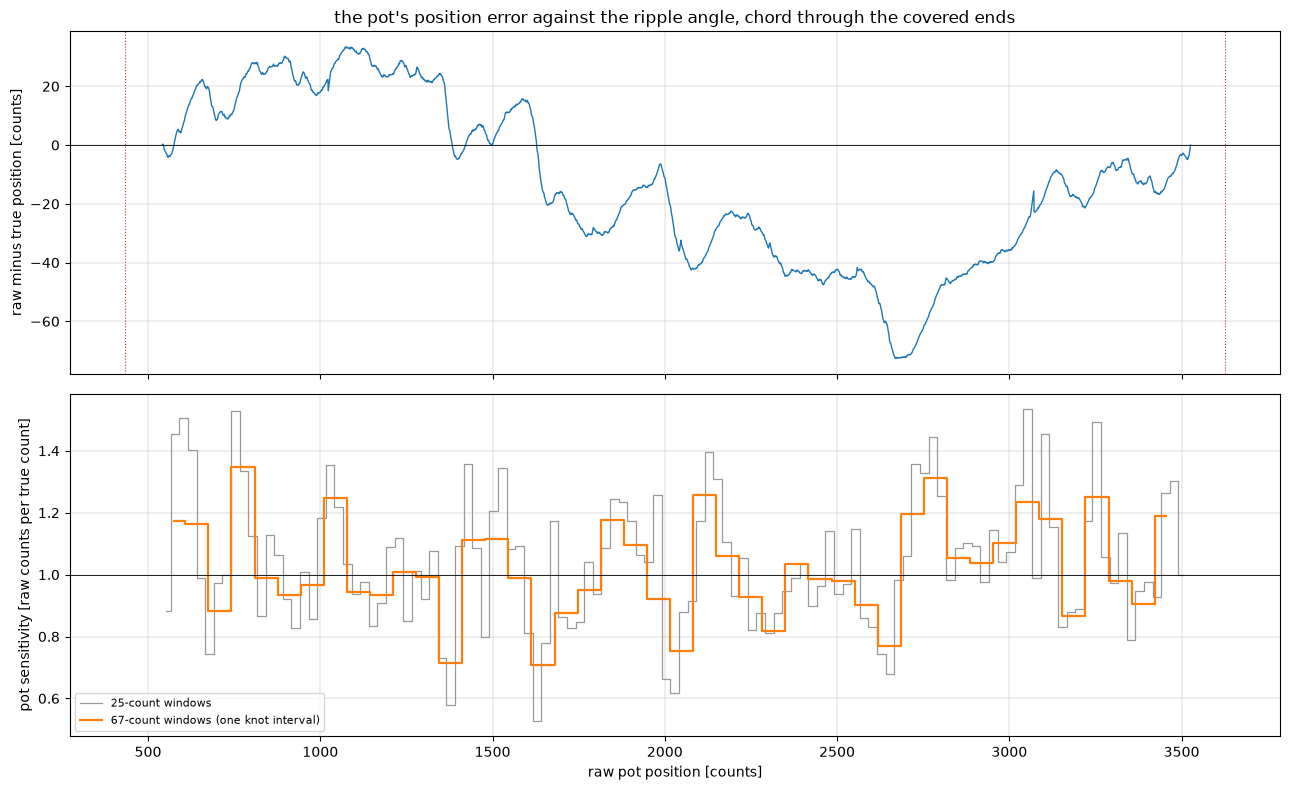

untrimmed coverage 493 .. 3552; at least 20 rungs over 541 .. 3526, 82.0% of the rails; 0.2599 ripple cycles per count on average
position error: raw minus true runs -72.6 .. +33.4 counts, 106.0 peak to peak


,sensitivity min,at,sensitivity max,at,max over min,speed error range [%]
window [raw counts],,,,,,
10,0.463,1366.0,6.611,3066.0,14.290,-54 .. +561
25,0.527,1628.5,1.534,3053.5,2.908,-47 .. +53
67,0.708,1646.5,1.347,775.5,1.901,-29 .. +35
200,0.845,1641.0,1.184,3041.0,1.401,-15 .. +18
500,0.914,1791.0,1.059,791.0,1.159,-9 .. +6


In [6]:
CORE = (15, 50)       # the duty band every route and every set tracks cleanly

def core(r, lo=CORE[0], hi=CORE[1]):
    return r["ok"] and lo <= abs(r["duty"]) <= hi

BAND = None           # set below: the stretch of travel at least 20 rungs cover

def chunks(rs, key="cyc", sel=core, band=True):
    # (pos, angle) from the first accepted sample to the end of each selected rung,
    # cut to BAND so a table's anchors never rest on one stray rung's extreme sample
    out = []
    for r in rs:
        if not sel(r):
            continue
        p, a = r["pos"][r["n0"]:], r[key][r["n0"]:]
        if band and BAND is not None:
            k = np.flatnonzero((p >= BAND[0]) & (p <= BAND[1]))
            if len(k) < 2:
                continue
            p, a = p[k[0]:k[-1] + 1], a[k[0]:k[-1] + 1]
        out.append((p, a))
    return out

S2 = rungs["2S session"]
st_all = potlut.stitch(chunks(S2), RAW_MIN, RAW_MAX)          # every accepted 2S core rung, untrimmed
well = np.flatnonzero(st_all.chunks >= 20) + RAW_MIN
BAND = (int(well.min()), int(well.max()))
st1 = potlut.stitch(chunks(S2), RAW_MIN, RAW_MAX)   # route 1, trimmed to BAND
LO, HI = st1.lo, st1.hi                             # the covered ends the table anchors on
x = np.arange(LO, HI + 1)                           # every covered raw count
lin = potlut.true_counts(st1, x)                    # the linearized count of each, no knots
C_LIN = (st1.cum[st1.lc] - st1.cum[st1.fc]) / (HI - LO)   # ripple cycles per linearized count

def sensitivity(xs, ys, w):
    # raw counts per linearized count over windows of w raw counts: 1 is the average,
    # above 1 the pot reads fast there, below 1 slow
    e = np.arange(xs[0], xs[-1] - w + 1, w)
    return e + w / 2, w / np.diff(np.interp(np.append(e, e[-1] + w), xs, ys))

dev = lin - x
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.plot(x, -dev, lw=1, color="tab:blue")
ax.axhline(0, color="k", lw=0.6)
for s in SOFT:
    ax.axvline(s, color="tab:red", lw=0.8, ls=":")
ax.set_ylabel("raw minus true position [counts]")
ax.set_title("the pot's position error against the ripple angle, chord through the covered ends")
ax.grid(True, lw=0.3)
ax = axes[1]
for w, col, lab in [(25, "0.6", "25-count windows"), (67, "tab:orange", "67-count windows (one knot interval)")]:
    c, s = sensitivity(x, lin, w)
    ax.step(c, s, where="mid", lw=0.9 if w == 25 else 1.6, color=col, label=lab)
ax.axhline(1, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("pot sensitivity [raw counts per true count]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

rows = []
for w in (10, 25, 67, 200, 500):
    c, s = sensitivity(x, lin, w)
    rows.append({"window [raw counts]": w, "sensitivity min": s.min(), "at": c[s.argmin()],
                 "sensitivity max": s.max(), "at ": c[s.argmax()], "max over min": s.max() / s.min(),
                 "speed error range [%]": f"{(s.min() - 1) * 100:+.0f} .. {(s.max() - 1) * 100:+.0f}"})
print(f"untrimmed coverage {st_all.lo} .. {st_all.hi}; at least 20 rungs over {LO} .. {HI}, {st1.coverage * 100:.1f}% of the rails; "
      f"{C_LIN:.4f} ripple cycles per count on average")
print(f"position error: raw minus true runs {(-dev).min():+.1f} .. {(-dev).max():+.1f} counts, "
      f"{(-dev).max() - (-dev).min():.1f} peak to peak")
pd.DataFrame(rows).set_index("window [raw counts]").round(3)

**What you are looking at.** Top, the raw reading minus the true position across the
covered travel, with the soft limits dotted. Bottom, the local sensitivity in 25-count
windows (grey) and in 67-count windows (orange), one table interval wide.

The raw pot wanders 106 counts peak to peak against the true angle, from +33 near raw
1100 to -73 near raw 2680. That is about 3% of the whole span, which sounds small, but
it is about 90 times the pot's rest noise of 1.2 counts, and it all comes in wiggles a few
hundred counts wide.

The sensitivity is the part that hurts speed. In 25-count windows it runs from 0.53 to
1.53, a factor of 2.9. In windows as wide as one knot interval it still runs from 0.71
to 1.35. The 10-count row is dominated by something else, a single code at raw 3072
that is eight codes wide (section 6), which is the converter and not the pot. For
comparison, notebook 06 found a 5.8x swing on the SG90 in 20 mV bins. The MG90's pot is
smoother than that, but a pot-derived speed still carries errors of roughly minus 30 to
plus 35% depending on position, and the position loop's gain in counts swings by the
same factor.

## 2. Route 1, the ripple

Each accepted rung gives a pot trace and a motor angle at every sample. The left plot
below is one 30% rung each way, the motor angle next to the pot travel scaled by the
average coupling. They track each other closely, which is the point of the whole
method, and the small differences between them are the pot.

The right plot is every accepted rung on its own. For each one I take its pot against
its motor angle, draw the straight line through its own two ends, and plot the
departure from that line. Each rung is independent, forward and reverse, twelve duties,
five captures, and they lie on top of each other.

**How the rungs are combined.** This follows `ident/src/lut.rs` step for step, and
`oscnb.potlut` is a port of it. For each rung, time step by time step, the motor angle
turned in that step is deposited into the pot count (or counts) the wiper sat on
during the step. Every count ends up holding the motor angle turned while the shaft
was there, the **density** in cycles per count, and a rung's deposits add up to exactly
its total angle. The pot's jitter of a count or two never reorders anything, because
the clock is the motor angle and it only ever moves forward. Rungs that cover the same
count are averaged, and the cumulative sum of the density is the true angle under each
raw count.

**How the table is fitted.** `lut.rs` then maps the covered ends onto their own
identity fractions, pins the rails at 0 and 1, and sets each knot's correction to the
count offset that lands it on the curve.

$$\text{corrected}(r_i) = r_i + c_i, \qquad r_i = r_{min} + i\,\frac{r_{max} - r_{min}}{54}$$

$$\text{linearize}(r) = \frac{\text{corrected}(r) - r_{min}}{r_{max} - r_{min}}$$

with straight lines between knots. I checked the port against the Rust code while
building this notebook. On three real rungs, with `lut::build` run through a scratch
example binary, the 55 corrections came out identical and `linearize` agreed to the
print precision (5e-10). The stitching step of `build_multi` is ported line by line
but was not run through Rust, because the Rust version computes its own phase from
the current and cannot take the ripple tracker's angle.

One consequence of the anchoring is worth saying out loud. Two tables built from rungs
that cover slightly different ends differ by a tilt, because each one is anchored on its
own ends. That tilt is a choice of reference and not a disagreement. Wherever this
notebook compares two builds, it removes it by taking both relative to the straight
line through two fixed counts (`potlut.chord_residual`), 1100 and 3050 unless it says
otherwise.

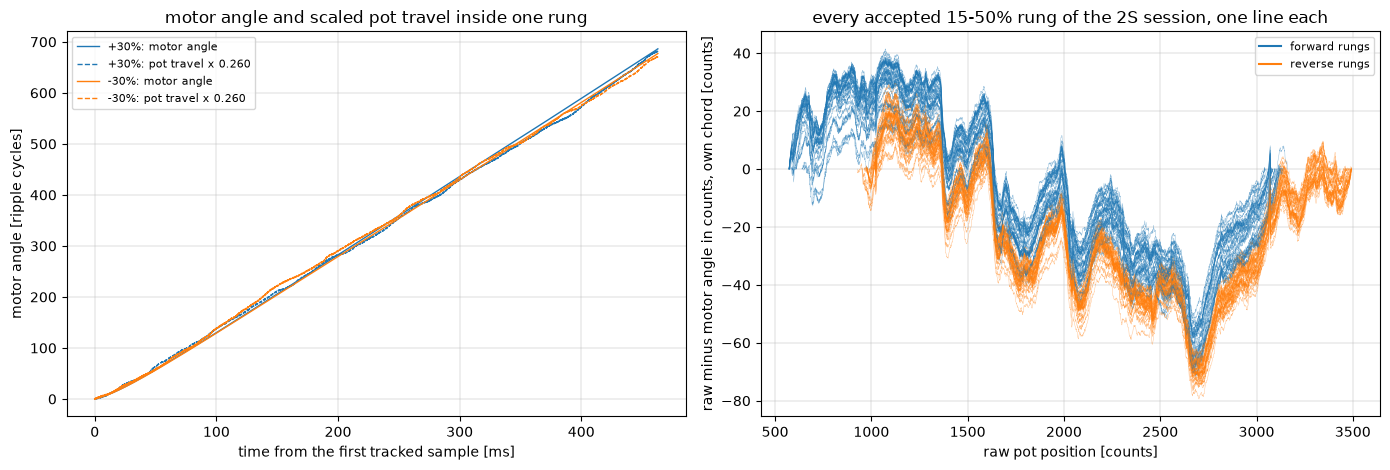

79 rungs; coverage by chunk count: [ 3 39 79] (min, 10th pct, median)


In [7]:
# One 30% rung each way: the motor angle and the pot against time, and the pot's
# departure from the motor angle inside the rung.
ex = [r for r in S2 if r["ok"] and r["cap"] == "capture-1" and abs(r["duty"]) == 30]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
for r, col in zip(ex, ["tab:blue", "tab:orange"]):
    n0 = r["n0"]
    t = np.arange(len(r["pos"]) - n0) * DT * 1e3
    ax.plot(t, r["cyc"][n0:] - r["cyc"][n0], color=col, lw=1, label=f"{r['duty']:+d}%: motor angle")
    ax.plot(t, np.abs(r["pos"][n0:] - r["pos"][n0]) * C_LIN, color=col, lw=1, ls="--",
            label=f"{r['duty']:+d}%: pot travel x {C_LIN:.3f}")
ax.set_xlabel("time from the first tracked sample [ms]")
ax.set_ylabel("motor angle [ripple cycles]")
ax.set_title("motor angle and scaled pot travel inside one rung")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
for r in S2:
    if not core(r):
        continue
    s = potlut.stitch(chunks([r], sel=lambda q: True), RAW_MIN, RAW_MAX)
    xs = np.arange(s.lo + 30, s.hi - 30)
    res = potlut.chord_residual(lambda z: potlut.true_counts(s, z), xs, xs[0], xs[-1])
    ax.plot(xs, -res, lw=0.3, alpha=0.5, color="tab:blue" if r["duty"] > 0 else "tab:orange")
ax.plot([], [], color="tab:blue", label="forward rungs")
ax.plot([], [], color="tab:orange", label="reverse rungs")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus motor angle in counts, own chord [counts]")
ax.set_title("every accepted 15-50% rung of the 2S session, one line each")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
print(f"{sum(core(r) for r in S2)} rungs; coverage by chunk count: "
      f"{np.percentile(st1.chunks[st1.fc:st1.lc], [0, 10, 50]).astype(int)} (min, 10th pct, median)")

**What you are looking at.** Left, one 30% rung forward (blue) and reverse (orange),
motor angle in solid and scaled pot travel in dashed, against time. Right, every
accepted rung's departure from its own straight line against raw position, forward in
blue and reverse in orange.

The rungs overlay to within a few counts everywhere. That is already most of proof rule
2 in one picture, and section 5 puts numbers on it.

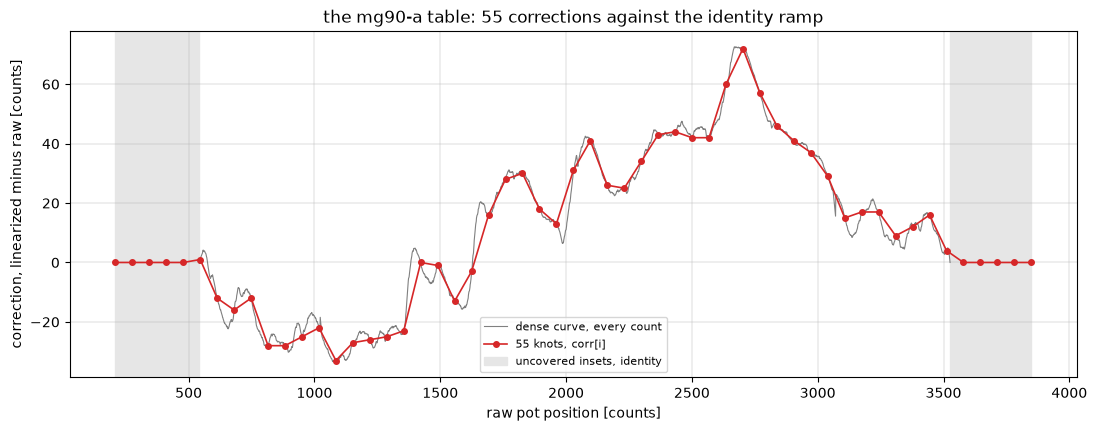

lut_corr = [0, 0, 0, 0, 0, 1, -12, -16, -12, -28, -28, -25, -22, -33, -27, -26, -25, -23, 0, -1, -13, -3, 16, 28, 30, 18, 13, 31, 41, 26, 25, 34, 43, 44, 42, 42, 60, 72, 57, 46, 41, 37, 29, 15, 17, 17, 9, 12, 16, 4, 0, 0, 0, 0, 0]
max |corr| 72 counts at raw 2703; endpoints map to themselves: counts(209) = 209.0, counts(3849) = 3849.0


In [8]:
LUT = potlut.from_stitch(st1, RAW_MIN, RAW_MAX)     # the table, lut.rs semantics
corr = np.array(LUT.corr)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(x, lin - x, lw=0.8, color="0.5", label="dense curve, every count")
ax.plot(LUT.knots, corr, "o-", ms=4, lw=1.2, color="tab:red", label="55 knots, corr[i]")
ax.axvspan(RAW_MIN, LO, color="0.9")
ax.axvspan(HI, RAW_MAX, color="0.9", label="uncovered insets, identity")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("correction, linearized minus raw [counts]")
ax.set_title("the mg90-a table: 55 corrections against the identity ramp")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()
print("lut_corr =", list(LUT.corr))
print(f"max |corr| {np.abs(corr).max()} counts at raw {LUT.knots[np.abs(corr).argmax()]:.0f}; "
      f"endpoints map to themselves: counts({RAW_MIN}) = {LUT.counts(RAW_MIN):.1f}, counts({RAW_MAX}) = {LUT.counts(RAW_MAX):.1f}")

The table itself. The grey curve is the dense correction, every count, and the red dots
are the 55 knots `lut.rs` would write. The shaded insets beyond 541 and 3526 are never
crossed by a well-covered rung, so the table leaves them at identity and tapers the
correction to zero across them. The soft limits (432 and 3626) sit inside those insets.

## 3. Route 2, the back-EMF

The second route has to reach the motor angle without the ripple and without the pot.
Back-EMF does it. A spinning motor generates a voltage proportional to its speed,
$e = K_e\,\omega$, and over one PWM period the motor's electrical equation gives

$$e = D\,(v_A - v_B) - R\,i$$

where $D$ is the duty, $v_A - v_B$ the crest-sampled terminal difference (the full rail
during the drive window, notebook 01) and $i$ the crest current. Integrating
$e / K_e$ over time gives motor angle.

The constant $K_e$ has to be in ripple units for the two routes to meet. I fit it against
the **ripple frequency** of each rung's settled window, never against the pot, so route 2
never touches the pot's scale. A free intercept $V_0$ goes in with it (notebook 08 found a
duty-dependent over-read at low duty) and forward and reverse get their own fit, since
the two directions sit a couple of percent apart. Current is a magnitude on this board,
low-side shunt, so it is never multiplied by the drive sign.

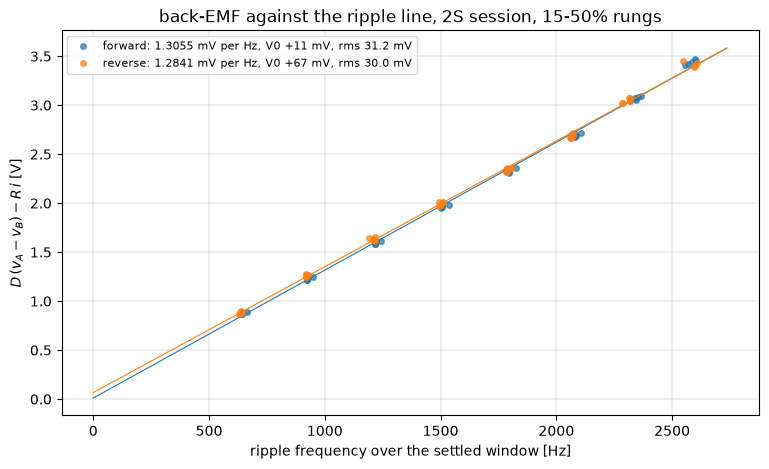

R 4.49 ohm: Ke fwd 1.3120 / rev 1.2926 mV per Hz, V0 +32 / +84 mV
R 4.89 ohm: Ke fwd 1.3055 / rev 1.2841 mV per Hz, V0 +11 / +67 mV
R 4.98 ohm: Ke fwd 1.3040 / rev 1.2821 mV per Hz, V0 +7 / +63 mV


In [9]:
# Route 2 needs back-EMF in ripple units. Over the settled window of every accepted
# 2S core rung: the period-mean terminal voltage D x (vA - vB) at the crest, minus
# R i, against the ripple frequency of the same window. The pot never enters.
def settled_point(r):
    a = int(len(r["pos"]) * 0.4)                                   # the last 60%
    if r["n0"] > a:
        return None
    D = np.abs(r["dq"][a:]) / Q15
    vd = (r["va"][a:].astype(float) - r["vb"][a:]) * np.sign(r["duty"]) * board.v_term_per_count
    i = r["cur"][a:] * board.a_per_count                           # current_raw is a magnitude, never signed
    f = (r["cyc"][-1] - r["cyc"][a]) / ((len(r["pos"]) - 1 - a) * DT)            # counted cycles over time
    return {"duty": r["duty"], "y": (D * vd).mean(), "i": i.mean(), "f": f, "valid": r["valid"][a:].mean()}

pts = pd.DataFrame([p for r in S2 if core(r) for p in [settled_point(r)] if p])
KE = {}
fig, ax = plt.subplots(figsize=(9, 5))
for sgn, col, lab in [(1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")]:
    g = pts[np.sign(pts.duty) == sgn]
    e = g.y - R_OHM * g.i                                          # back-EMF in volts
    k, v0 = np.polyfit(g.f, e, 1)                                  # EMF on speed, not the other way
    KE[sgn] = (k, v0)
    ax.plot(g.f, e, "o", ms=4, color=col, alpha=0.7, label=f"{lab}: {k * 1e3:.4f} mV per Hz, V0 {v0 * 1e3:+.0f} mV, "
            f"rms {np.std(e - (k * g.f + v0)) * 1e3:.1f} mV")
    ff = np.linspace(0, g.f.max() * 1.05, 10)
    ax.plot(ff, k * ff + v0, color=col, lw=0.8)
ax.set_xlabel("ripple frequency over the settled window [Hz]")
ax.set_ylabel(r"$D\,(v_A - v_B) - R\,i$ [V]")
ax.set_title("back-EMF against the ripple line, 2S session, 15-50% rungs")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

# sensitivity to R across its bracket, same fit
m = servo.measured["r_winding_measured"]
for rr in (m.lo, m.value, m.hi):
    ks = [np.polyfit(pts[np.sign(pts.duty) == s].f, pts[np.sign(pts.duty) == s].y - rr * pts[np.sign(pts.duty) == s].i, 1)
          for s in (1, -1)]
    print(f"R {rr:.2f} ohm: Ke fwd {ks[0][0] * 1e3:.4f} / rev {ks[1][0] * 1e3:.4f} mV per Hz, "
          f"V0 {ks[0][1] * 1e3:+.0f} / {ks[1][1] * 1e3:+.0f} mV")

**What you are looking at.** Each dot is one rung's settled window, back-EMF against the
ripple frequency of the same window, forward in blue and reverse in orange, with each
direction's line. The printed rows refit the same thing at both ends of the $R$
bracket.

The fit is tight, about 30 mV rms against 0.9 to 3.5 V of EMF, and $K_e$ comes out 1.306 mV per ripple Hz forward
and 1.284 reverse, 1.7% apart, with intercepts of 11 and 67 mV. Moving $R$ across its
whole bracket moves $K_e$ by less than 1%, because the current barely changes between
15 and 50% duty. So the bracket on $R$ matters little for the scale, and the next cells
show what it does to the shape.

First the paired comparison, rung by rung. Each rung now has two motor angles on the
same samples, one from counting ripple and one from integrating back-EMF. For each rung
I compare the two shapes over the rung's own covered stretch, each against its own
straight line, so nothing about $K_e$'s scale can enter.

Per rung the two routes differ by 1.7 to 3.5 counts rms against a shape of 90 to 97
counts peak to peak. The largest single-rung differences, 5 to 11 counts, are at 15 to
25% forward. The total angle from route 2 lands within 2% of route 1 in every band.

In [10]:
def bemf_cycles(r, r_ohm=R_OHM, ke=None):
    # Motor angle from back-EMF: per sample EMF over Ke, integrated. Same samples
    # as route 1, a different clock.
    k, v0 = (ke or KE)[int(np.sign(r["duty"]))]
    D = np.abs(r["dq"]) / Q15
    vd = (r["va"].astype(float) - r["vb"]) * np.sign(r["duty"]) * board.v_term_per_count
    e = D * vd - r_ohm * r["cur"] * board.a_per_count - v0
    return np.cumsum(e / k) * DT

for rs in rungs.values():
    for r in rs:
        if r["ok"]:
            r["cyc2"] = bemf_cycles(r)

# Paired, rung by rung: each route's shape over the rung's own covered interval.
rows = []
for r in S2:
    if not core(r):
        continue
    s1 = potlut.stitch(chunks([r], "cyc", lambda q: True), RAW_MIN, RAW_MAX)
    s2 = potlut.stitch(chunks([r], "cyc2", lambda q: True), RAW_MIN, RAW_MAX)
    a, b = max(s1.lo, s2.lo) + 30, min(s1.hi, s2.hi) - 30
    xs = np.arange(a, b)
    r1 = potlut.chord_residual(lambda z: potlut.true_counts(s1, z), xs, a, b - 1)
    r2 = potlut.chord_residual(lambda z: potlut.true_counts(s2, z), xs, a, b - 1)
    rows.append({"duty": r["duty"], "shape pk-pk [counts]": np.ptp(r1),
                 "route 2 minus route 1, rms [counts]": np.std(r2 - r1),
                 "max [counts]": np.abs(r2 - r1).max(),
                 "cycles, route 2 over route 1": (r["cyc2"][-1] - r["cyc2"][r["n0"]]) / (r["cyc"][-1] - r["cyc"][r["n0"]])})
paired = pd.DataFrame(rows)
paired["dir"] = np.where(paired.duty > 0, "fwd", "rev")
paired["band"] = pd.cut(paired.duty.abs(), [14, 25, 40, 50], labels=["15-25%", "30-40%", "45-50%"])
paired.groupby(["band", "dir"], observed=True).mean(numeric_only=True).drop(columns="duty").round(3)

shape pk-pk [counts]  route 2 minus route 1, rms [counts]  max [counts]  cycles, route 2 over route 1
band   dir                                                                                                       
15-25% fwd                95.622                                3.538        10.902                         1.018
       rev                92.948                                2.479         8.884                         1.011
30-40% fwd                97.444                                3.072         9.653                         0.996
       rev                89.361                                2.225         7.211                         0.995
45-50% fwd                89.854                                1.776         5.801                         1.010
       rev                89.104                                1.699         4.993                         1.009

Now the pooled shapes, over the stretch from 1100 to 3050 where both directions run at
full speed, and the proof rule.

**The stated uncertainty.** Both routes read the same samples, so the capture-to-capture
scatter they share cancels in their difference. The honest error bar on the difference is
twice the standard error of the per-capture differences, plus the largest shape change
across the $R$ bracket. That bar is small, 0.6 counts median.

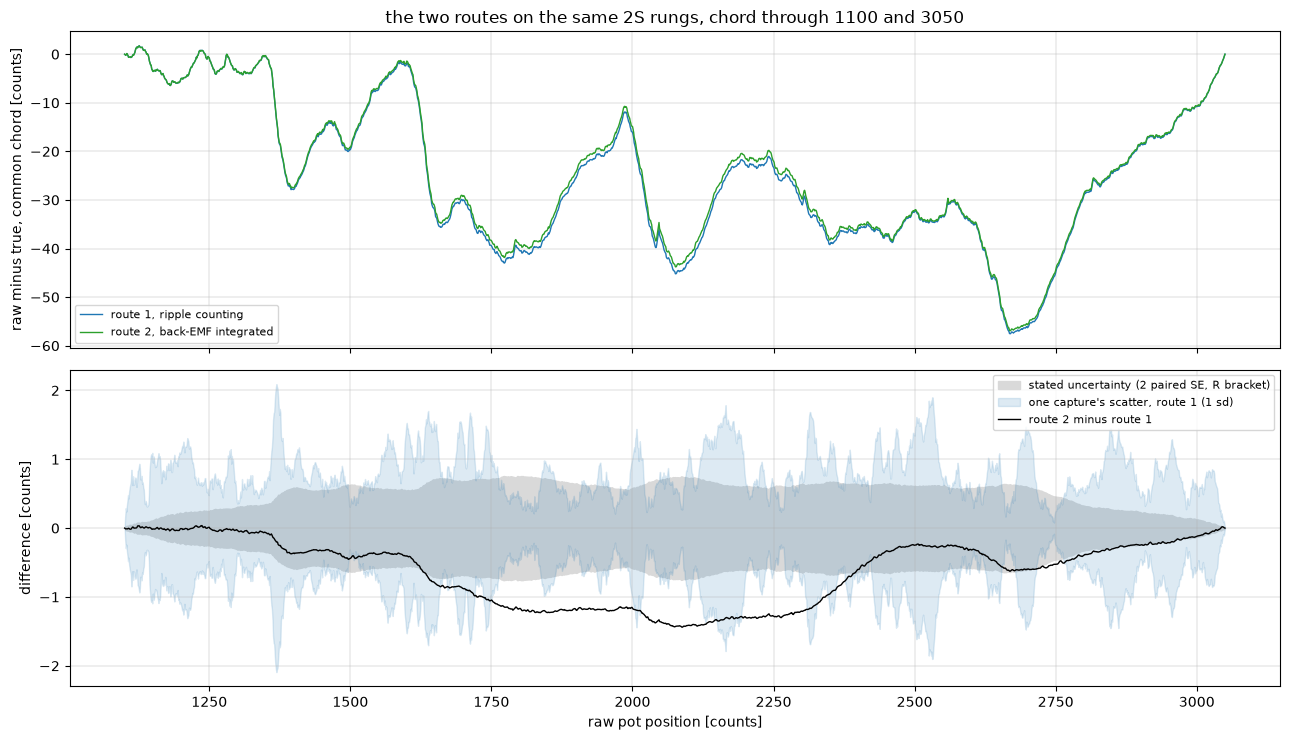

,value,unit
quantity,,
"route 1 shape, peak to peak",59.3,counts
"route 2 minus route 1, rms",0.47,counts
"route 2 minus route 1, max |.|",1.44,counts
"stated uncertainty, median / max",0.60 / 0.76,counts
counts outside the stated uncertainty,53.3,% of the interval
"R bracket alone, max",0.45,counts
"one capture's scatter, route 1, median / max sd",0.74 / 2.09,counts


In [11]:
st2 = potlut.stitch(chunks(S2, "cyc2"), RAW_MIN, RAW_MAX)
LUT2 = potlut.from_stitch(st2, RAW_MIN, RAW_MAX)
A, B = 1100, 3050                                    # common interval, well inside both directions' coverage
xc = np.arange(A, B + 1)
shape = lambda st, xs=xc: potlut.chord_residual(lambda z: potlut.true_counts(st, z), xs, A, B)

def per_capture(rs, key):
    # the pooled shape of each capture alone, in the common chord gauge
    caps = sorted({r["cap"] for r in rs})
    return np.array([shape(potlut.stitch(chunks(rs, key, lambda r, c=c: core(r) and r["cap"] == c), RAW_MIN, RAW_MAX))
                     for c in caps])

P1, P2 = per_capture(S2, "cyc"), per_capture(S2, "cyc2")
d12 = shape(st2) - shape(st1)
# The two routes read the same samples, so their capture scatter is shared. The
# standard error of the difference comes from the per-capture differences.
se = (P2 - P1).std(0, ddof=1) / np.sqrt(len(P1))
# route 2's own systematic: R across its bracket, Ke refitted at each end
m = servo.measured["r_winding_measured"]
def route2_stitch_at(rr):
    ke = {}
    for s in (1, -1):
        g = pts[np.sign(pts.duty) == s]
        ke[s] = tuple(np.polyfit(g.f, g.y - rr * g.i, 1))
    cs = [(r["pos"][r["n0"]:], bemf_cycles(r, rr, ke)[r["n0"]:]) for r in S2 if core(r)]
    return potlut.stitch(cs, RAW_MIN, RAW_MAX)
st2_lo, st2_hi = route2_stitch_at(m.lo), route2_stitch_at(m.hi)
r_sys = np.maximum(np.abs(shape(st2_lo) - shape(st2)), np.abs(shape(st2_hi) - shape(st2)))
U = 2 * se + r_sys                                 # stated uncertainty: 2 paired SE plus the R bracket

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
ax = axes[0]
ax.plot(xc, -shape(st1), lw=1, color="tab:blue", label="route 1, ripple counting")
ax.plot(xc, -shape(st2), lw=1, color="tab:green", label="route 2, back-EMF integrated")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title(f"the two routes on the same 2S rungs, chord through {A} and {B}")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.fill_between(xc, -U, U, color="0.85", label="stated uncertainty (2 paired SE, R bracket)")
ax.fill_between(xc, -P1.std(0, ddof=1), P1.std(0, ddof=1), color="tab:blue", alpha=0.15,
                label="one capture's scatter, route 1 (1 sd)")
ax.plot(xc, d12, lw=1, color="k", label="route 2 minus route 1")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame([
    ("route 1 shape, peak to peak", f"{np.ptp(shape(st1)):.1f}", "counts"),
    ("route 2 minus route 1, rms", f"{np.std(d12):.2f}", "counts"),
    ("route 2 minus route 1, max |.|", f"{np.abs(d12).max():.2f}", "counts"),
    ("stated uncertainty, median / max", f"{np.median(U):.2f} / {U.max():.2f}", "counts"),
    ("counts outside the stated uncertainty", f"{(np.abs(d12) > U).mean() * 100:.1f}", "% of the interval"),
    ("R bracket alone, max", f"{r_sys.max():.2f}", "counts"),
    ("one capture's scatter, route 1, median / max sd", f"{np.median(P1.std(0, ddof=1)):.2f} / {P1.std(0, ddof=1).max():.2f}", "counts"),
], columns=["quantity", "value", "unit"]).set_index("quantity")

**What you are looking at.** Top, the pooled shape from each route over the common
interval, raw minus true against a straight line through 1100 and 3050. Bottom, route 2
minus route 1 in black, the stated uncertainty in grey, and one capture's own scatter in
light blue for scale.

The two routes land on top of each other. They differ by 0.47 counts rms and 1.4 counts
at most, on a shape 59 counts peak to peak. By the letter of the rule that difference is
**resolved**, since it leaves the grey band over half the interval. So route 2 carries a
small systematic of about a count that the $R$ bracket does not explain. It is also smaller
than the scatter of one capture (sd up to 2.1 counts), a third of what 55 knots leave
behind (section 6), and about the size of the pot's rest noise. Over this stretch I call
proof rule 1 **met**, with that residual stated.

The middle is not the whole table. Below about 900 only forward rungs pass, and each of
them spends its first 80 to 500 counts (more at higher duty) still spinning up. Above about 3200 the same is true of the reverse
rungs. The next plot compares the routes over the whole covered range, as a ratio of the
two densities in 50-count windows so any disagreement shows up where it happens.

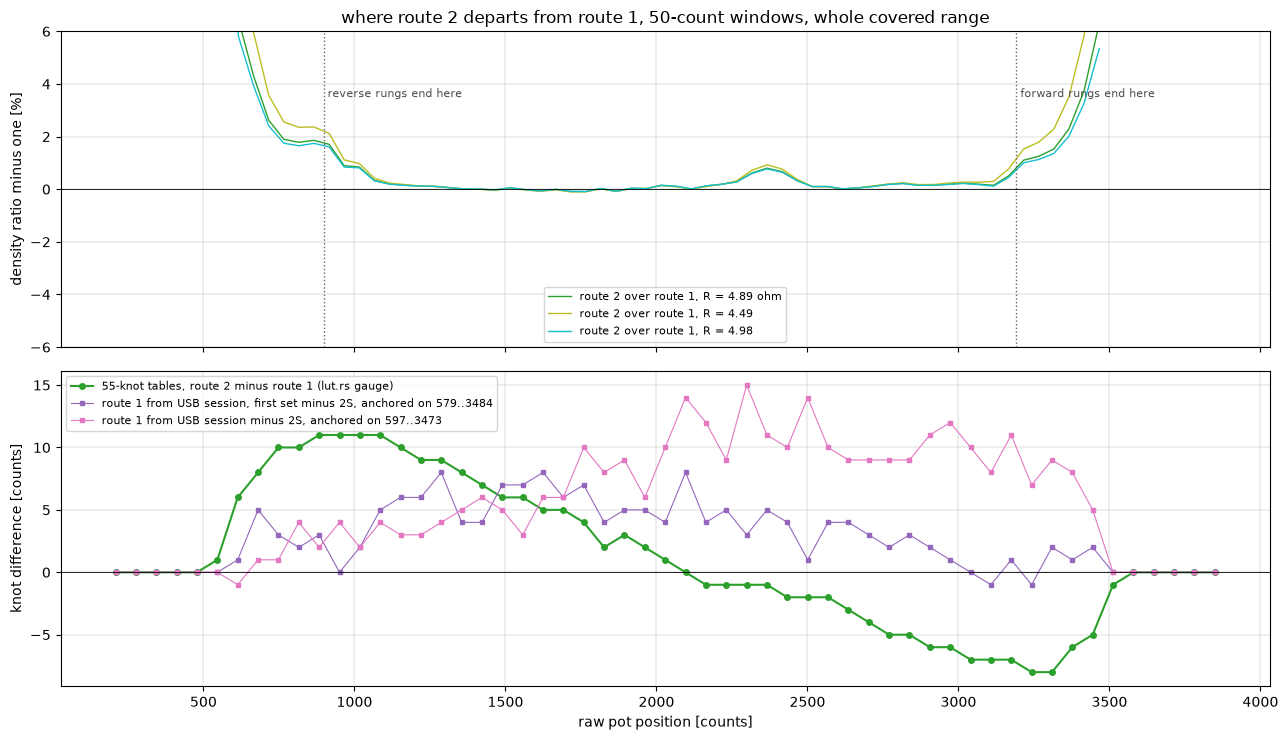

55-knot tables, route 2 minus route 1: max |.| 11 counts overall, 10 inside 1100..3050, 11 at the ends


mean [%]  rms [%]  max |.| [%]
end                        duty band                                
541..1000 (forward rungs)  15-20%        -0.58     2.17         6.08
                           25-30%        -0.92     2.32         6.45
                           35-40%        -0.75     2.31         6.77
                           45-50%        -0.68     2.61         7.24
3150..3526 (reverse rungs) 15-20%        -0.08     0.85         1.29
                           25-30%        -0.12     0.54         0.79
                           35-40%        -0.03     0.88         2.06
                           45-50%         0.44     0.95         2.10

In [12]:
# The whole covered range, where only one direction runs past each end. Route 2
# against route 1 as a density ratio in 50-count windows, so a disagreement shows
# where it happens instead of being smeared by an integral.
def density50(st, lo=LO, hi=HI, w=50):
    e = np.arange(lo, hi - w + 1, w)
    return e + w / 2, np.diff(st.angle(np.append(e, e[-1] + w))) / w

c50, d1 = density50(st1)
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
ax = axes[0]
for st, col, lab in [(st2, "tab:green", f"R = {R_OHM:g} ohm"), (st2_lo, "tab:olive", f"R = {m.lo:g}"), (st2_hi, "tab:cyan", f"R = {m.hi:g}")]:
    ax.plot(c50, (density50(st)[1] / d1 - 1) * 100, lw=1, color=col, label=f"route 2 over route 1, {lab}")
cover_f = potlut.stitch(chunks(S2, "cyc", lambda r: core(r) and r["duty"] > 0), RAW_MIN, RAW_MAX)
cover_r = potlut.stitch(chunks(S2, "cyc", lambda r: core(r) and r["duty"] < 0), RAW_MIN, RAW_MAX)
for xx_, lab in ((cover_r.lo, "reverse rungs end here"), (cover_f.hi, "forward rungs end here")):
    ax.axvline(xx_, color="0.4", ls=":", lw=1)
    ax.text(xx_, 3.5, " " + lab, fontsize=8, color="0.3")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylim(-6, 6)
ax.set_ylabel("density ratio minus one [%]")
ax.set_title("where route 2 departs from route 1, 50-count windows, whole covered range")
ax.legend(fontsize=8, loc="lower center")
ax.grid(True, lw=0.3)
ax = axes[1]
kd = np.array(LUT2.corr) - np.array(LUT.corr)
ax.plot(LUT.knots, kd, "o-", ms=4, color="tab:green", label="55-knot tables, route 2 minus route 1 (lut.rs gauge)")
# route 1 from the USB sessions, which spin up at a different current and speed
for name, col in (("USB session, first set", "tab:purple"), ("USB session", "tab:pink")):
    su = potlut.stitch(chunks(rungs[name]), RAW_MIN, RAW_MAX)
    wu = np.flatnonzero(su.chunks >= 0.25 * su.chunks.max()) + RAW_MIN   # this set's well-covered stretch
    a, b = max(LO, wu.min()), min(HI, wu.max())    # both tables anchored on ends both sets cover well
    xs = np.arange(a, b + 1)
    table = lambda st: potlut.fit_knots(xs, (st.angle(xs) - st.angle(a)) / (st.angle(b) - st.angle(a)), RAW_MIN, RAW_MAX)
    ax.plot(LUT.knots, np.array(table(su).corr) - np.array(table(st1).corr), "s-", ms=3, lw=0.8, color=col,
            label=f"route 1 from {name} minus 2S, anchored on {a}..{b}")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("knot difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
ends = (LUT.knots < A) | (LUT.knots > B)
print(f"55-knot tables, route 2 minus route 1: max |.| {np.abs(kd).max()} counts overall, "
      f"{np.abs(kd[~ends]).max()} inside {A}..{B}, {np.abs(kd[ends]).max()} at the ends")

# Route 1 at the ends, split by duty band. Spin-up covers 80 to 500 counts depending on
# duty, so a spin-up bias in route 1 would make these bands disagree in a duty order.
rows = []
for sgn, (lo, hi) in ((1, (LO, 1000)), (-1, (3150, HI))):
    c0, d0 = density50(st1, lo, hi)
    for bl, bh in ((15, 20), (25, 30), (35, 40), (45, 50)):
        sb = potlut.stitch(chunks(S2, "cyc", lambda r: core(r, bl, bh) and np.sign(r["duty"]) == sgn), RAW_MIN, RAW_MAX)
        _, db = density50(sb, lo, hi)
        rel = (db / d0 - 1) * 100
        rows.append({"end": f"{lo}..{hi} ({'forward' if sgn > 0 else 'reverse'} rungs)", "duty band": f"{bl}-{bh}%",
                     "mean [%]": rel.mean(), "rms [%]": np.sqrt(np.mean(rel ** 2)), "max |.| [%]": np.abs(rel).max()})
pd.DataFrame(rows).set_index(["end", "duty band"]).round(2)

**What you are looking at.** Top, route 2's density over route 1's minus one, in percent,
for the pinned $R$ and both ends of its bracket, with the dotted lines where each
direction's rungs stop. Bottom, the 55-knot tables' knot-by-knot difference between the
routes (green), and route 1 from each USB dataset minus 2S route 1 (purple and pink),
each pair anchored on ends both sets cover well.

In the middle the density ratio sits within 1% of zero, the agreement above. Toward both
ends it climbs steadily, to 2% where only one direction runs and beyond 6% over the first
couple of hundred counts of every rung. The spin-up region is exactly where route 2 is
weakest. The current is several times its settled value there, so any error in $R\,i$, or
the inductive term I leave out, lands straight in the speed. Once anchored, those ends tilt
the whole route-2 table by up to 11 counts at a knot.

Route 1 at the ends has other checks. The spin-up length changes six-fold between 15% and
50% duty (about 80 to 500 counts). If spin-up biased route 1, its density near the ends
would follow the duty. The last table splits the end stretches by duty band. Every band's
mean sits within 1% of the pooled density (-0.9 to +0.4%), with no order in duty, and the
50-count scatter is 1 to 2.6% rms, which is what a quarter of the rungs gives. The USB route-1 tables, whose rungs spin up at a lower current, stay within 8 counts
(the first set) and 15 counts (the set recorded alongside this notebook) of 2S at every
knot, and their difference is a broad hump through the middle rather than something at
the ends. So a lower spin-up current does not visibly change route 1 at the ends. Section
5 comes back to the hump.

**Verdict on proof rule 1.** Met over 1100 to 3050, with a resolved residual of 1.4 counts
at most. **Not met** at the two ends, roughly 540 to 1100 and 3050 to 3530, where route 2
cannot be trusted during spin-up. The table there rests on route 1 alone, supported by its
independence from duty. That is a real gap, and the open questions at the bottom say what
capture would close it.

## 4. Backlash

The gears have play. When the motor reverses it turns a little before the teeth on the
other flank engage and the output starts to follow. That is backlash, and on the pot axis
it would show up as forward and reverse traces offset by a constant.

The stitch works on density, cycles per count, and a constant offset between two traces
has no density. So backlash cannot leak into the table, and the claim "forward and reverse
differ only by a constant offset" turns into something testable. Forward-only and
reverse-only tables should have the same shape. The next cell checks that.

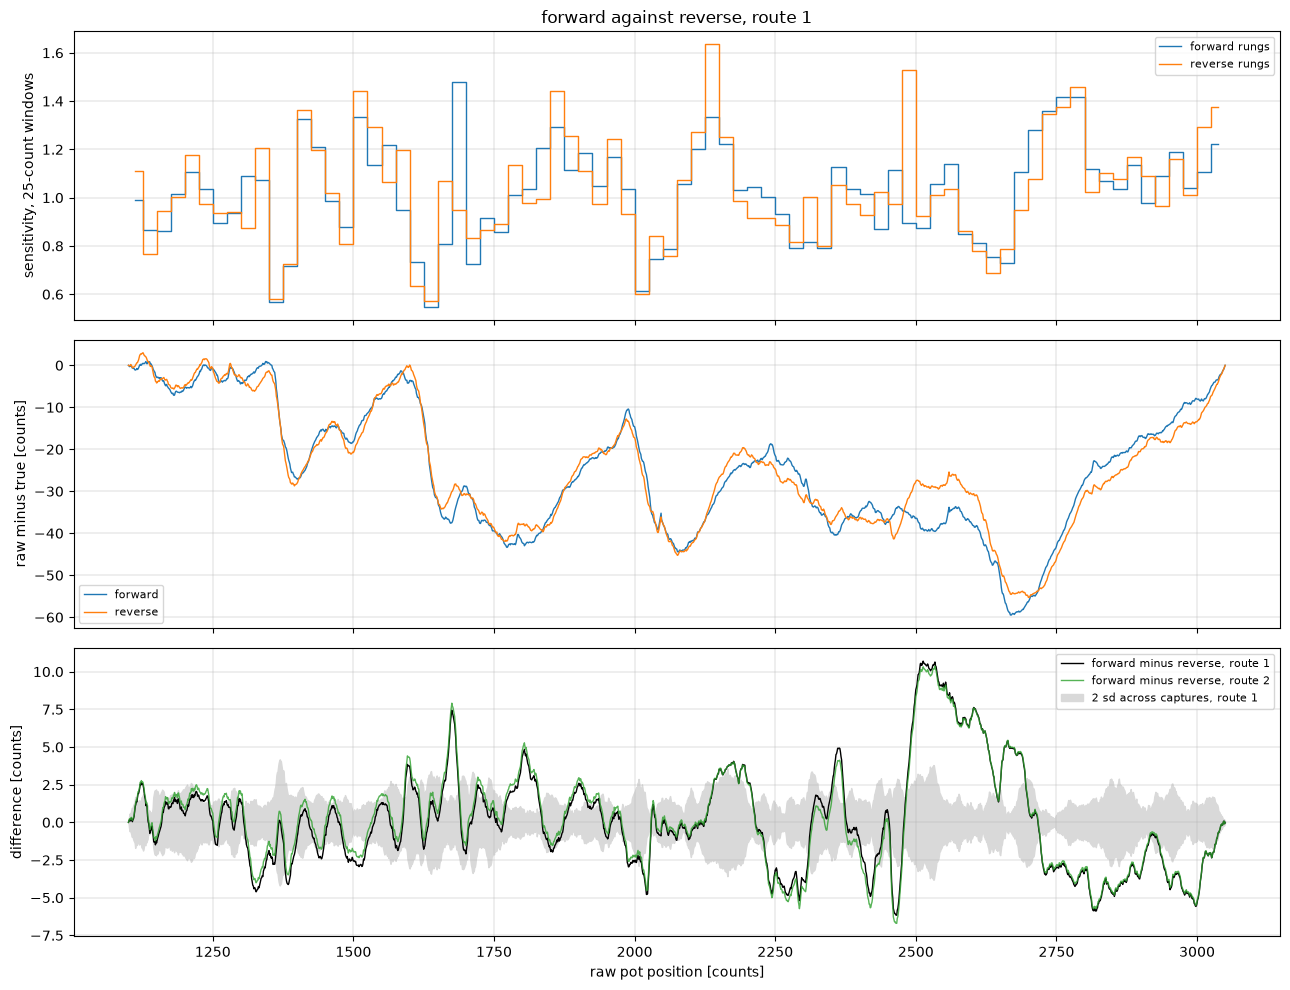

forward minus reverse, route 1: rms 3.38, max 10.7 counts at raw 2513; route 2: rms 3.36, max 10.4; the two routes' differences correlate r = 0.993
45.6% of the interval differs by more than twice the capture scatter of a difference


,settled current [A],"fwd minus rev, rms [counts]",peak in 2400..2750 [counts]
duty band,,,
15-25%,0.064,3.532,11.533
30-40%,0.080,3.325,10.322
45-50%,0.093,3.418,10.938


,"fwd minus rev, rms [counts]"
reverse map shifted by [counts],
-6,3.74
-4,3.56
-2,3.43
0,3.38
2,3.41
4,3.49
6,3.66


In [13]:
sel_f = lambda r: core(r) and r["duty"] > 0
sel_r = lambda r: core(r) and r["duty"] < 0
sf1, sr1 = (potlut.stitch(chunks(S2, "cyc", s), RAW_MIN, RAW_MAX) for s in (sel_f, sel_r))
sf2, sr2 = (potlut.stitch(chunks(S2, "cyc2", s), RAW_MIN, RAW_MAX) for s in (sel_f, sel_r))
dfr1, dfr2 = shape(sf1) - shape(sr1), shape(sf2) - shape(sr2)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax = axes[0]
for s, col, lab in [(sf1, "tab:blue", "forward rungs"), (sr1, "tab:orange", "reverse rungs")]:
    c, v = sensitivity(xc, potlut.true_counts(s, xc), 25)
    ax.step(c, v, where="mid", color=col, lw=1, label=lab)
ax.set_ylabel("sensitivity, 25-count windows")
ax.set_title("forward against reverse, route 1")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.plot(xc, -shape(sf1), color="tab:blue", lw=1, label="forward")
ax.plot(xc, -shape(sr1), color="tab:orange", lw=1, label="reverse")
ax.set_ylabel("raw minus true [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[2]
ax.plot(xc, dfr1, color="k", lw=1, label="forward minus reverse, route 1")
ax.plot(xc, dfr2, color="tab:green", lw=1, alpha=0.8, label="forward minus reverse, route 2")
ax.fill_between(xc, -2 * P1.std(0, ddof=1), 2 * P1.std(0, ddof=1), color="0.85", label="2 sd across captures, route 1")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
k = np.abs(dfr1).argmax()
print(f"forward minus reverse, route 1: rms {np.std(dfr1):.2f}, max {np.abs(dfr1).max():.1f} counts at raw {xc[k]}; "
      f"route 2: rms {np.std(dfr2):.2f}, max {np.abs(dfr2).max():.1f}; the two routes' differences correlate "
      f"r = {np.corrcoef(dfr1, dfr2)[0, 1]:.3f}")
out = np.abs(dfr1) > 2 * np.sqrt(2) * P1.std(0, ddof=1)
print(f"{out.mean() * 100:.1f}% of the interval differs by more than twice the capture scatter of a difference")

# A test of one candidate cause. If the difference were the train winding up under
# its load, it would grow with the drive current. Split by duty band: the current
# rises about half again from 15-25% to 45-50%.
rows = []
peak = (xc > 2400) & (xc < 2750)
for lo, hi in ((15, 25), (30, 40), (45, 50)):
    f_ = potlut.stitch(chunks(S2, "cyc", lambda r: core(r, lo, hi) and r["duty"] > 0), RAW_MIN, RAW_MAX)
    r_ = potlut.stitch(chunks(S2, "cyc", lambda r: core(r, lo, hi) and r["duty"] < 0), RAW_MIN, RAW_MAX)
    d = shape(f_) - shape(r_)
    cur = np.mean([np.mean(r["cur"][int(len(r["cur"]) * 0.4):]) * board.a_per_count
                   for r in S2 if core(r, lo, hi)])
    rows.append({"duty band": f"{lo}-{hi}%", "settled current [A]": cur, "fwd minus rev, rms [counts]": np.std(d),
                 "peak in 2400..2750 [counts]": d[peak].max()})
display(pd.DataFrame(rows).set_index("duty band").round(3))

# A second candidate. Play in the pot's own coupling (the plastic D-key) or wiper
# hysteresis would shift the whole reverse map along the pot axis by a few counts. Slide
# it and see which shift lines the two directions up best.
rows = []
for dsh in range(-6, 7, 2):
    shifted = potlut.chord_residual(lambda z: potlut.true_counts(sr1, np.asarray(z) + dsh), xc, A, B)
    rows.append({"reverse map shifted by [counts]": dsh, "fwd minus rev, rms [counts]": np.std(shape(sf1) - shifted)})
pd.DataFrame(rows).set_index("reverse map shifted by [counts]").round(2)

**What you are looking at.** Top, sensitivity in 25-count windows from forward rungs
(blue) and reverse rungs (orange). Middle, the two shapes against the common chord. Bottom,
forward minus reverse from route 1 (black) and route 2 (green), with twice one capture's
scatter in grey.

Mostly they agree, which is the constant-offset picture. But not entirely. The difference
is 3.4 counts rms and reaches 10.7 counts near raw 2513, and it goes beyond the capture
scatter over 46% of the interval. Route 2 sees the same difference (10.4 counts, correlation
0.993), so this is the output and the pot, not the tracker. The largest feature is a bump
between about 2450 and 2700 that the forward pass reads higher than the reverse.

The last table tests one candidate cause. If this were the train winding up elastically
under its load, the difference would grow with the drive current. The current rises by
half from the 15-25% band to the 45-50% band, and the difference does not move (10.3 to
11.5 counts at the peak, no trend). So wind-up under drive current is not it.

The second table tests another. Play in the pot's own coupling to the output (a plastic D-key
on this servo), or plain wiper hysteresis, would slide the whole reverse map a few counts along
the pot axis. Sliding it back should then line the two directions up. It does not. The best
shift is zero, and every shift makes the match worse, so a constant pot-side offset is ruled
out to within a couple of counts. What is left is local, and a story until tested (the open
questions list the test). The two candidates I have are a wiper that contacts the track
slightly differently each way over one textured patch, and tooth transmission error that
differs between the two flanks of a mesh.

For the table this means the combined curve averages the two directions, and each
direction on its own is off by up to about 5 counts near that bump. That is about what
55 knots leave behind anyway. The firmware table has one curve, not two.

The constant part of the backlash, measured directly. Each session capture has a reversal
block, a 60 ms drive at 20% or 40% then an immediate flip to the opposite sign, chained with
no gap. This is notebook 06's method. After the flip the pot stops, turns round and comes
back. While it sits within 2 counts of its turning point, I count the commutation steps in
the current, which the motor makes while the output stands still. The step detector is the
one from notebook 06, a one-sample jump of at least 10% of the local current, rerun at 8% and
12% to show the count does not hang on the threshold.

In [14]:
PLATEAU = 2           # counts: the pot 'stands still' within this of its extreme (nb06 sec 7)
EDGE = 10             # samples ignored at both ends of the post-flip segment

def flip_pairs(meta):
    # (segment before, segment after) for every chained flip: a then: step after a drive step
    sched, n = meta["schedule"], len(meta["schedule"])
    return [(p * n + k, p * n + k + 1) for p in range(len(meta["dirs"])) for k, e in enumerate(sched)
            if e.startswith("then:") and not sched[k - 1].startswith(("coast", "brake"))]

def flip(pre, post, bias):
    # nb06's dwell method: commutation steps counted while the pot sits on its turning point
    old = np.sign(pre.cmd_duty_q15.iloc[0])
    x = post.current_raw.to_numpy().astype(float) - bias
    p = post.pos.to_numpy().astype(float) * old                      # old direction positive
    ps = np.convolve(p, np.ones(20) / 20, mode="same")                # 1 ms smoothing
    top = ps[EDGE:-EDGE].max()
    w = np.where(np.abs(ps - top) <= PLATEAU)[0]
    w = w[(w >= EDGE) & (w < len(p) - EDGE)]
    out = {"duty": int(round(abs(pre.cmd_duty_q15.iloc[0]) * 100 / Q15)), "from": "fwd" if old > 0 else "rev",
           "at_raw": top * old, "dwell_ms": (w.max() - w.min()) * DT * 1e3}
    for frac in (0.08, 0.10, 0.12):                                   # threshold sensitivity, as nb06
        ev = ripple.step_events(x, frac=frac)
        ev = ev[(ev >= EDGE) & (ev < len(x) - EDGE)]
        out[f"cycles, {int(frac * 100)}% threshold"] = int(np.sum((ev > w.min()) & (ev < w.max())))
    return out

def plays(d, label, view="reversal"):
    rows = []
    for cap, df, meta in frames(d, view):
        bias = df[df.seg == 0].current_raw.mean()
        for a, b in flip_pairs(meta):
            rows.append({"set": label, "cap": cap, **flip(df[df.seg == a], df[df.seg == b], bias)})
    return rows

play = pd.DataFrame(plays(ds, "2S session") + plays(ds_usb, "USB session") + plays(ds_usb_old, "USB session, first set")
                    + plays(ds_classic, "2S classic"))
play["cycles"] = play["cycles, 10% threshold"]
play["counts, mean coupling"] = play["cycles"] / C_LIN      # cycles over cycles per linearized count
play.groupby(["set", "duty", "from"]).agg(
    flips=("cycles", "size"), cycles=("cycles", "mean"),
    cycles_8pct=("cycles, 8% threshold", "mean"), cycles_12pct=("cycles, 12% threshold", "mean"),
    counts=("counts, mean coupling", "mean"), dwell_ms=("dwell_ms", "mean")).round(2)

flips  cycles  cycles_8pct  cycles_12pct  counts  dwell_ms
set                    duty from                                                            
2S classic             20   fwd       2     1.0          1.0           1.0    3.85     11.75
                            rev       2     2.0          2.0           1.5    7.69     10.07
                       40   fwd       2     1.5          1.5           1.5    5.77      7.15
                            rev       2     1.5          1.5           1.0    5.77      7.22
2S session             20   fwd      10     1.7          1.7           1.7    6.54      9.39
                            rev      10     1.1          1.1           1.1    4.23      8.06
                       40   fwd      10     1.7          1.7           1.7    6.54      7.05
                            rev      10     1.4          1.4           1.4    5.39      6.08
USB session            20   fwd      10     1.7          2.0           1.4    6.54     13.19
                            rev      10     0.9          1.0           0.8    3.46     11.16
                       40   fwd      10     1.2          1.3           1.2    4.62      8.29
                            rev      10     1.2          1.2           1.2    4.62      7.28
USB session, first set 20   fwd      10     1.6          1.8           1.3    6.16     13.71
                            rev      10     1.5          1.6           1.4    5.77     12.53
                       40   fwd      10     1.5          1.6           1.5    5.77      8.74
                            rev      10     1.0          1.0           1.0    3.85      7.50

In [15]:
g = play.groupby("set")["cycles"]
pd.DataFrame({"flips": g.size(), "cycles, mean": g.mean(), "cycles, sd": g.std(),
              "counts, mean": g.mean() / C_LIN, "counts, sd": g.std() / C_LIN}).round(2)

,flips,"cycles, mean","cycles, sd","counts, mean","counts, sd"
set,,,,,
2S classic,8,1.50,0.93,5.77,3.56
2S session,40,1.48,0.85,5.68,3.26
USB session,40,1.25,0.93,4.81,3.57
"USB session, first set",40,1.40,0.90,5.39,3.46


The play is **about 1.5 ripple cycles**, a quarter of a motor revolution, which is about 6
counts of pot at the average coupling. The four datasets agree (1.25 to 1.50 cycles), the
threshold hardly matters, and the counts are small integers, so each flip is only good to a
cycle or so and the mean over 40 flips is what carries. For comparison the SG90 in notebook 06
had about 3 cycles, as you would expect from a metal train against a plastic one.

The table cannot and should not remove this. It is a hysteresis between approach directions,
about 6 counts, and it is the same whether the pot is linearized or not.

## 5. Repeatability

Proof rule 2 wants the table to come out the same across repeats. I check five things.

- Each of the five 2S captures on its own.
- Forward against reverse (section 4).
- Duty bands, 15-25, 30-40, 45-50 and 55-100%, one direction at a time so every band covers
  the same stretch.
- Supply, the two USB sessions against 2S.
- Method and day, the classic 2S grid and steady-step experiments from a day earlier.

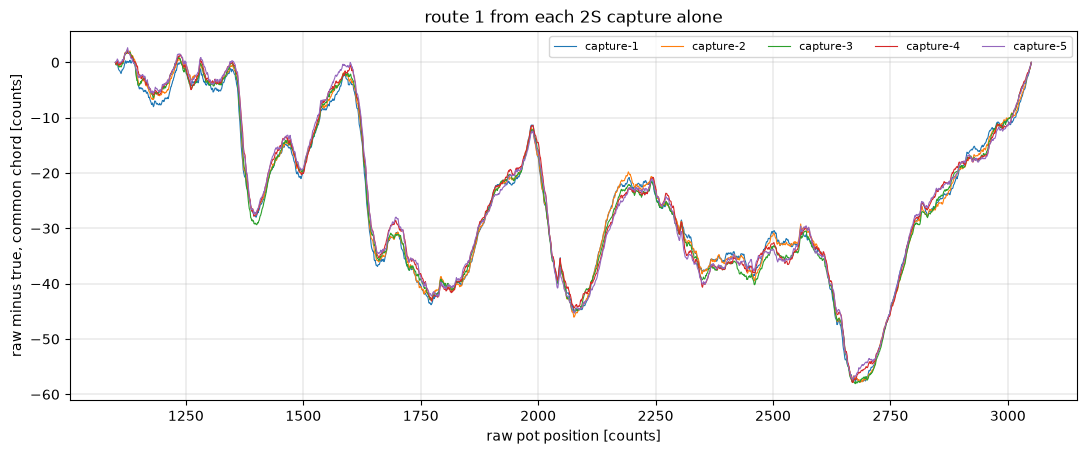

,builds,"sd, mean [counts]","sd, max [counts]","range, max [counts]"
set,,,,
"2S session, capture to capture, route 1",5,0.81,2.09,5.31
"2S session, capture to capture, route 2",5,0.89,2.08,5.12
"2S session, duty bands 15-25/30-40/45-50/55-100, fwd",4,1.18,3.08,6.77
"2S session, duty bands 15-25/30-40/45-50/55-100, rev",4,0.59,2.26,5.03


In [16]:
fig, ax = plt.subplots(figsize=(13, 4.8))
caps = sorted({r["cap"] for r in S2})
for c, sh in zip(caps, P1):
    ax.plot(xc, -sh, lw=0.8, label=c)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title("route 1 from each 2S capture alone")
ax.legend(fontsize=8, ncol=5)
ax.grid(True, lw=0.3)
plt.show()

def spread_row(label, M):
    sd = M.std(0, ddof=1)
    return {"set": label, "builds": len(M), "sd, mean [counts]": sd.mean(), "sd, max [counts]": sd.max(),
            "range, max [counts]": np.ptp(M, axis=0).max()}

def band_shape(rs, lo, hi, sgn=None):
    sel = lambda r: core(r, lo, hi) and (sgn is None or np.sign(r["duty"]) == sgn)
    s = potlut.stitch(chunks(rs, "cyc", sel), RAW_MIN, RAW_MAX)
    return shape(s) if s is not None and s.lo <= A and s.hi >= B else None

rows = [spread_row("2S session, capture to capture, route 1", P1),
        spread_row("2S session, capture to capture, route 2", P2)]
# duty bands, one direction at a time so every band covers the same stretch
for sgn, lab in ((1, "fwd"), (-1, "rev")):
    Mb = [band_shape(S2, lo, hi, sgn) for lo, hi in ((15, 25), (30, 40), (45, 50), (55, 100))]
    rows.append(spread_row(f"2S session, duty bands 15-25/30-40/45-50/55-100, {lab}", np.array([m for m in Mb if m is not None])))
pd.DataFrame(rows).set_index("set").round(2)

**What you are looking at.** The route-1 shape from each 2S capture alone, against the common
chord.

The five captures overlay. Capture to capture the shape moves 0.8 counts (sd, averaged over
the interval), 2.1 counts at worst. Route 2 repeats the same way. The duty bands agree to about
1 count sd, 3 counts at worst, including the 55-100% rungs, whose ripple line runs at 2.8 to 4.5 kHz
against 0.65 to 2.6 kHz in the core band.

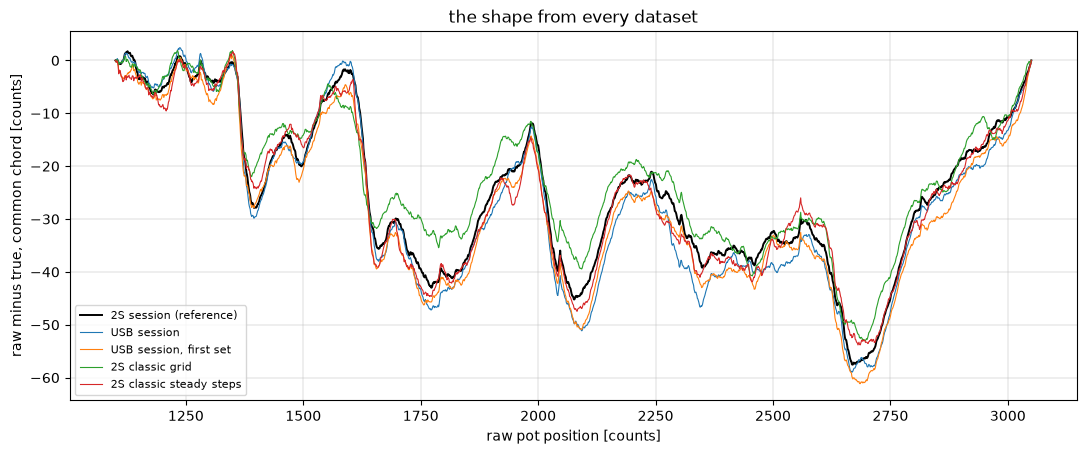

,rungs,rms vs 2S session [counts],max |.| [counts],covered,"cycles per count, A..B","2S session, A..B"
set,,,,,,
USB session,70,2.303,8.953,556 .. 3493,0.268,0.268
"USB session, first set",70,1.520,6.879,558 .. 3513,0.267,0.268
2S classic grid,160,3.270,10.188,539 .. 3527,0.266,0.268
2S classic steady steps,20,2.378,6.485,539 .. 3524,0.268,0.268


In [17]:
# The same shape from every other dataset, against the 2S session. USB is a check
# of direction only, and the classic set was captured a day earlier on older timing.
ref = shape(st1)
rows = []
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(xc, -ref, color="k", lw=1.4, label="2S session (reference)")
for name, rs in rungs.items():
    if name == "2S session":
        continue
    s = potlut.stitch(chunks(rs), RAW_MIN, RAW_MAX)
    if s is None or s.lo > A or s.hi < B:
        rows.append({"set": name, "rungs": sum(core(r) for r in rs), "note": "does not cover the common interval"})
        continue
    d = shape(s) - ref
    ax.plot(xc, -shape(s), lw=0.8, label=name)
    rows.append({"set": name, "rungs": sum(core(r) for r in rs), "rms vs 2S session [counts]": np.std(d),
                 "max |.| [counts]": np.abs(d).max(), "covered": f"{s.lo} .. {s.hi}",
                 # ripple cycles per raw count over the common interval, a mechanical number
                 "cycles per count, A..B": (s.angle(B) - s.angle(A)) / (B - A),
                 "2S session, A..B": (st1.angle(B) - st1.angle(A)) / (B - A)})
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title("the shape from every dataset")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()
pd.DataFrame(rows).set_index("set").round(3)

**What you are looking at.** The shape from every other dataset against the 2S session, same
chord.

The USB sets agree with 2S to 1.5 to 2.3 counts rms, 7 to 9 at worst. The coupling over the
common interval is the same to within 0.8% on every set (0.266 to 0.268 cycles per count), which
is a mechanical number and should not care about the supply. The older classic grid is the
furthest off, 3.3 rms and 10 counts at worst. It was captured a day earlier on the same servo,
and I have no data yet that says whether the pot changed overnight, the rig was reassembled, or
something in the older capture timing differs. It is listed as open.

Anchored on their own well-covered ends (section 3 plot), the USB tables sit up to 8 and 15
counts above the 2S table in a broad hump through the middle. That is larger than the 2S
capture-to-capture scatter, so it is a supply difference or a USB capture difference and
not noise. It is listed as open. The supply policy keeps it out of the table either way.

The last repeatability check is the gear itself. `ident/src/slip.rs` splits a constant-duty run
into ten equal pieces, drops the two at the rails, and compares counts per motor revolution
across the rest. A slipping or stripped mesh makes one piece collapse. It flags a run above a
coefficient of variation of 0.20 or with any piece under 40% of the median. It runs here on every
accepted rung of every set, once on raw counts, as the firmware tool would today, and once on
linearized counts.

In [18]:
# slip.rs on every accepted rung, first on raw counts as the firmware tool would,
# then on linearized counts.
rows = []
for name, rs in rungs.items():
    for r in rs:
        if not r["ok"]:
            continue
        p, ph = r["pos"][r["n0"]:], r["cyc"][r["n0"]:] / 6.0      # the metric is order independent
        for how, pp in (("raw", p), ("linearized", LUT.counts(p))):
            m = potlut.slip_metrics(pp, ph)
            if m:
                rows.append({"set": name, "counts": how, **m})
slip = pd.DataFrame(rows)
slip.groupby(["set", "counts"]).agg(runs=("slip_cov", "size"), cov_median=("slip_cov", "median"),
                                    cov_max=("slip_cov", "max"), min_over_median=("min_over_median", "min"),
                                    stuck=("stuck_count", "sum"), flagged=("flagged", "sum")).round(3)

runs  cov_median  cov_max  min_over_median  stuck  flagged
set                     counts                                                                
2S classic grid         linearized   269       0.027    0.051            0.903      0        0
                        raw          269       0.060    0.092            0.859      0        0
2S classic steady steps linearized    24       0.031    0.061            0.871      0        0
                        raw           24       0.096    0.116            0.780      0        0
2S session              linearized   134       0.023    0.040            0.924      0        0
                        raw          134       0.073    0.094            0.796      0        0
USB session             linearized   156       0.024    0.042            0.917      0        0
                        raw          156       0.077    0.105            0.791      0        0
USB session, first set  linearized   156       0.023    0.050            0.892      0        0
                        raw          156       0.060    0.094            0.845      0        0

Nothing slips. No run is flagged and no piece is stuck, in any set. The metric itself is worth a
look, though. On raw counts its median is 0.06 to 0.10, and almost all of that is the pot's own
nonlinearity. Linearized, it drops to 0.02 to 0.03. So a linearized pot makes the slip check about
three times more sensitive for free, which is worth carrying into `osc`.

## 6. The 55-knot table

The firmware block holds 55 corrections, one every 67.4 counts. The questions are how much of the
error that leaves, what a finer table would buy, and whether the fine texture under a knot interval
matters for position.

The next table fits 28 to 433 knots to the same dense curve and measures what is left, in counts
of position and in percent of local sensitivity.

In [19]:
# How much a 55-knot table leaves behind, against the dense curve it was fitted to,
# and what a finer table would buy. Position error in counts, sensitivity error in %.
rows = []
for n in (28, 55, 109, 217, 433):
    L = potlut.from_stitch(st1, RAW_MIN, RAW_MAX, n_knots=n)
    e = L.counts(x) - lin
    _, s_tab = sensitivity(x, L.counts(x), 25)
    _, s_den = sensitivity(x, lin, 25)
    rows.append({"knots": n, "spacing [counts]": (RAW_MAX - RAW_MIN) / (n - 1), "firmware bytes": 2 * n,
                 "position error rms [counts]": e.std(), "max [counts]": np.abs(e).max(),
                 "25-count sensitivity error rms [%]": np.std(s_tab / s_den - 1) * 100})
rows.append({"knots": "identity", "spacing [counts]": np.nan, "firmware bytes": 0,
             "position error rms [counts]": (x - lin).std(), "max [counts]": np.abs(x - lin).max(),
             "25-count sensitivity error rms [%]": np.std(1 / sensitivity(x, lin, 25)[1] - 1) * 100})
pd.DataFrame(rows).set_index("knots").round(2)

,spacing [counts],firmware bytes,position error rms [counts],max [counts],25-count sensitivity error rms [%]
knots,,,,,
28,134.81,56,5.02,13.69,17.49
55,67.41,110,3.54,14.86,14.78
109,33.70,218,1.41,7.90,8.00
217,16.85,434,0.75,7.74,4.48
433,8.43,866,0.43,6.40,2.29
identity,NaN,0,27.51,72.61,21.64


For **position**, 55 knots cut the error from 27.5 counts rms to 3.5 (72.6 to 14.9 at worst). The
leftover is the texture between knots. Going to 217 knots would take it to 0.75.

For **sensitivity**, and so for speed, the picture is different. Identity leaves 21.6% rms in
25-count windows and 55 knots still leave 14.8%. A good share of the pot's texture is narrower than
67 counts and a straight line between knots simply cannot follow it. 109 knots halve that and 217
knots get it to 4.5%. At two bytes a knot, 217 knots are 434 bytes.

At the very finest scale, one raw count, the density says how much true travel each ADC code
spans. An average code is 1.

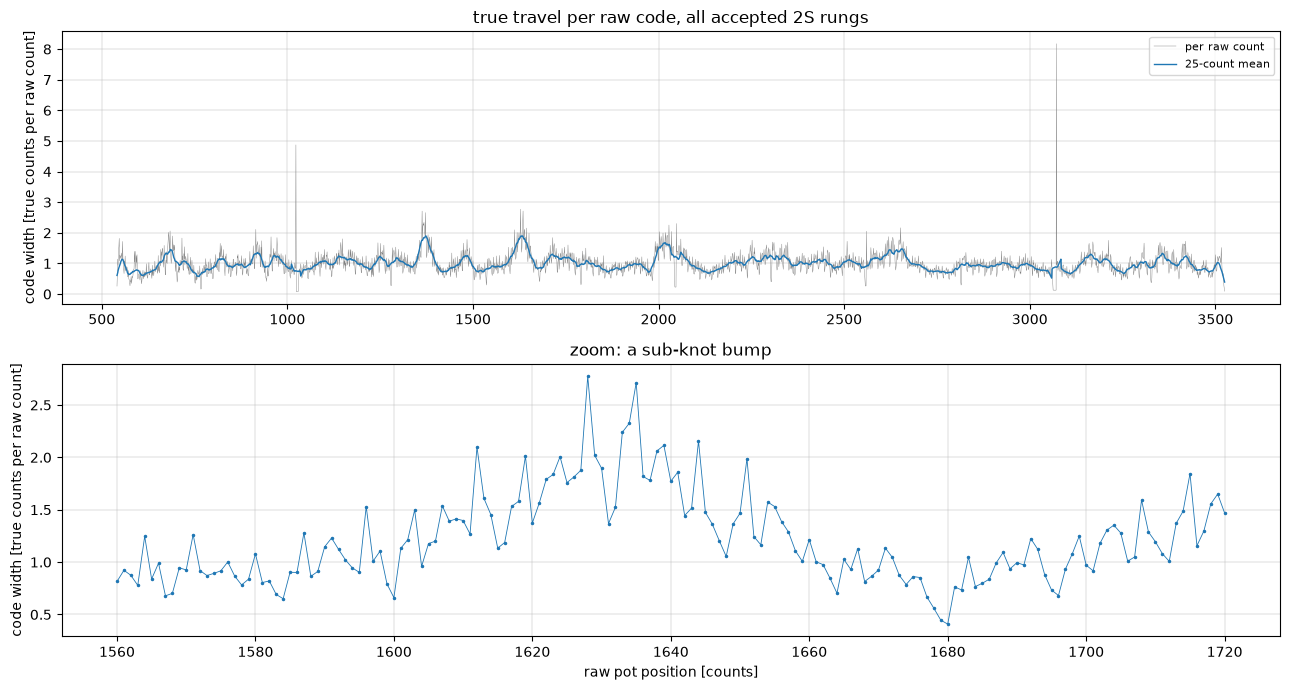

widest codes (raw count: width in average codes): {3072: 8.18, 1023: 4.87, 1628: 2.77, 1635: 2.71, 1363: 2.71, 1372: 2.66}


In [20]:
# The finest scale there is: ripple cycles deposited per single raw count, pooled.
dens = st1.density[st1.fc:st1.lc] / C_LIN          # 1 = an average-width code
xx = np.arange(st1.fc, st1.lc) + RAW_MIN
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
ax = axes[0]
ax.plot(xx, dens, lw=0.3, color="0.5", label="per raw count")
ax.plot(xx, np.convolve(dens, np.ones(25) / 25, "same"), lw=1, color="tab:blue", label="25-count mean")
ax.set_ylabel("code width [true counts per raw count]")
ax.set_title("true travel per raw code, all accepted 2S rungs")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
z = (xx >= 1560) & (xx <= 1720)
ax.plot(xx[z], dens[z], ".-", lw=0.6, ms=3)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("code width [true counts per raw count]")
ax.set_title("zoom: a sub-knot bump")
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
wide = pd.Series(dens, index=xx).nlargest(6)
print("widest codes (raw count: width in average codes):", {int(k): round(v, 2) for k, v in wide.items()})

**What you are looking at.** Top, true travel per raw code across the covered range, per code in
grey and a 25-count mean in blue. Bottom, a zoom on one bump.

Two separate things live here. The spikes are single codes, 3072 at 8.2 codes wide and 1023 at 4.9,
at the converter's major bit transitions. That is the ADC's differential nonlinearity, not the pot.
A wide code is a dead band, the reading simply sits there for about eight codes of travel, and no
correction table can split it. Near those two codes position is only good to about plus or minus 4
counts whatever the table does.

The bumps are the pot. They are 20 to 50 counts wide, the one in the zoom near 1630 is about 40, and
they are what drives the sensitivity numbers above.

Does the texture matter for position? The 55-knot table leaves 3.5 counts rms and about 15 counts at
worst against the dense curve. The pot's rest noise is 1.2 counts and the backlash about 6. So for
position, 55 knots are adequate, the worst case is a sub-knot bump of the kind in the zoom. For speed
the texture matters a lot, and section 8 is where that decides something.

The table in the form `osc` and the firmware block take it. The same numbers are written to
`captures/mg90/pot-lut-mg90-a.json` in the bringup repo.

In [21]:
print(LUT.to_json(dataset=ds.key, rungs=int(sum(core(r) for r in S2)), covered=[int(LO), int(HI)],
                  source="notebooks/09-pot-linearization.ipynb, route 1 (ripple), 2S session, 15-50% rungs, both directions"))

{
  "raw_min": 209,
  "raw_max": 3849,
  "lut_corr": [
    0,
    0,
    0,
    0,
    0,
    1,
    -12,
    -16,
    -12,
    -28,
    -28,
    -25,
    -22,
    -33,
    -27,
    -26,
    -25,
    -23,
    0,
    -1,
    -13,
    -3,
    16,
    28,
    30,
    18,
    13,
    31,
    41,
    26,
    25,
    34,
    43,
    44,
    42,
    42,
    60,
    72,
    57,
    46,
    41,
    37,
    29,
    15,
    17,
    17,
    9,
    12,
    16,
    4,
    0,
    0,
    0,
    0,
    0
  ],
  "dataset": "mg90-a__2s",
  "rungs": 79,
  "covered": [
    541,
    3526
  ],
  "source": "notebooks/09-pot-linearization.ipynb, route 1 (ripple), 2S session, 15-50% rungs, both directions"
}


## 7. Before and after on held-out captures

A table fitted and scored on the same rungs flatters itself. Here each 2S capture takes a turn as the
test set while the table is built from the other four, and the tables built from all five 2S captures
are also scored on the two USB sessions and the classic grid, none of which went into them.

On each held-out rung the truth is the rung's own ripple angle, with an offset and a scale fitted per
rung, so only shape counts. Speed is the pot differenced over a window of $W$ samples,

$$\hat v_{pot}[k] = \frac{\theta[k] - \theta[k - W]}{W\,T_s}$$

scored against the ripple over the same window, in percent of the rung's mean speed.

In [22]:
# Leave one capture out: build from four 2S captures, test on the fifth, rotate.
# Truth on a held-out rung is its own ripple angle, with an offset and a scale fitted
# per rung (the chord gauge), so the error is shape only.
M0 = 400              # 20 ms after the first tracked sample
WINDOWS = (20, 80, 160, 400)   # 1, 4, 8, 20 ms

def evaluate(test, maps, label):
    pos_rows, spd = [], []
    for r in test:
        if not r["ok"]:
            continue
        n0 = r["n0"] + M0
        p, cyc = r["pos"][n0:], r["cyc"][n0:] * np.sign(r["duty"])
        for name, fn in maps.items():
            y = fn(p)
            k, a = np.polyfit(cyc, y, 1)            # counts per cycle and offset, this rung
            e = y - (a + k * cyc)
            pos_rows.append({"set": label, "cap": r["cap"], "duty": r["duty"], "map": name, "rms": e.std(), "max": np.abs(e).max()})
            for W in WINDOWS:
                vp = (y[W:] - y[:-W]) / (W * DT)
                vr = k * (cyc[W:] - cyc[:-W]) / (W * DT)
                spd.append(pd.DataFrame({"set": label, "duty": r["duty"], "map": name, "W": W,
                                         "at": (p[W:] + p[:-W]) / 2, "err_pct": (vp - vr) / np.abs(vr).mean() * 100,
                                         "cap": r["cap"]}))
    return pd.DataFrame(pos_rows), pd.concat(spd, ignore_index=True)

pos_ev, spd_ev = [], []
for c in caps:
    s = potlut.stitch(chunks([r for r in S2 if r["cap"] != c]), RAW_MIN, RAW_MAX)
    L55 = potlut.from_stitch(s, RAW_MIN, RAW_MAX)
    xs = np.arange(s.lo, s.hi + 1)
    dense_c = potlut.true_counts(s, xs)
    maps = {"raw": lambda p: p.astype(float), "55 knots": L55.counts,
            "217 knots": potlut.from_stitch(s, RAW_MIN, RAW_MAX, n_knots=217).counts,
            "dense": lambda p, xs=xs, d=dense_c: np.interp(p, xs, d)}
    a, b = evaluate([r for r in S2 if r["cap"] == c], maps, "2S held out")
    pos_ev.append(a); spd_ev.append(b)
# the full 2S table applied to the other supply and the older sets
maps_full = {"raw": lambda p: p.astype(float), "55 knots": LUT.counts,
             "217 knots": potlut.from_stitch(st1, RAW_MIN, RAW_MAX, n_knots=217).counts,
             "dense": lambda p: np.interp(p, x, lin)}
for name in ("USB session", "USB session, first set", "2S classic grid"):
    a, b = evaluate(rungs[name], maps_full, name)
    pos_ev.append(a); spd_ev.append(b)
pos_ev, spd_ev = pd.concat(pos_ev), pd.concat(spd_ev)
ORDER = ["raw", "55 knots", "217 knots", "dense"]
pv = pos_ev.pivot_table(index="set", columns="map", values="rms", aggfunc="mean")[ORDER]
pm = pos_ev.pivot_table(index="set", columns="map", values="max", aggfunc="median")[ORDER]
print("position error per held-out rung, rms [counts], mean over rungs")
display(pv.round(2))
print("position error per held-out rung, max |.| [counts], median over rungs")
display(pm.round(1))
print("pot speed error, rms over all held-out samples [% of rung mean speed]")
display(spd_ev.groupby(["set", "W", "map"]).err_pct.std().unstack("map")[ORDER].rename(
    index=lambda w: f"{w * DT * 1e3:g} ms" if isinstance(w, (int, np.integer)) else w, level=1).round(2))

position error per held-out rung, rms [counts], mean over rungs


map,raw,55 knots,217 knots,dense
set,,,,
2S classic grid,13.51,5.39,4.78,4.88
2S held out,16.54,4.55,2.82,2.76
USB session,17.57,5.14,3.32,3.26
"USB session, first set",15.20,4.75,3.22,3.18


position error per held-out rung, max |.| [counts], median over rungs


map,raw,55 knots,217 knots,dense
set,,,,
2S classic grid,37.7,18.7,15.6,16.2
2S held out,46.3,17.9,11.4,11.3
USB session,54.7,19.5,14.3,14.4
"USB session, first set",41.8,19.4,13.0,12.9


pot speed error, rms over all held-out samples [% of rung mean speed]


map                             raw  55 knots  217 knots  dense
set                    W                                       
2S classic grid        1 ms   55.89     54.74      55.24  55.27
                       4 ms   22.05     18.86      16.54  16.97
                       8 ms   17.44     13.48      10.96  11.40
                       20 ms  11.85      7.40       5.65   5.90
2S held out            1 ms   57.57     55.41      54.46  53.87
                       4 ms   24.06     19.29      12.55  11.56
                       8 ms   19.89     14.10       7.58   7.07
                       20 ms  14.35      7.98       3.70   3.49
USB session            1 ms   80.15     78.83      79.49  79.37
                       4 ms   27.26     23.03      16.98  16.03
                       8 ms   22.60     17.22      10.89  10.27
                       20 ms  16.90     10.52       5.70   5.43
USB session, first set 1 ms   82.49     81.48      82.49  82.44
                       4 ms   26.77     22.63      16.99  16.11
                       8 ms   22.02     16.84      10.97  10.50
                       20 ms  16.15      9.96       5.52   5.34

Position gets much better. On held-out 2S captures the rms error per rung goes from 16.5 counts raw to
4.6 with 55 knots and 2.8 with the dense curve, and the worst sample per rung from 46 to 18 to 11. The
USB sessions and the classic grid show the same thing (13.5 to 17.6 raw, 4.8 to 5.4 with 55 knots), so the
table carries across supply and day.

Speed gets less better. At 4 ms the pot's error goes from 24% to 19% with 55 knots, and to 12.6% with
217 knots. At 20 ms, 14.4% to 8.0% and 3.7%. At 1 ms everything is about 55% because noise dominates.

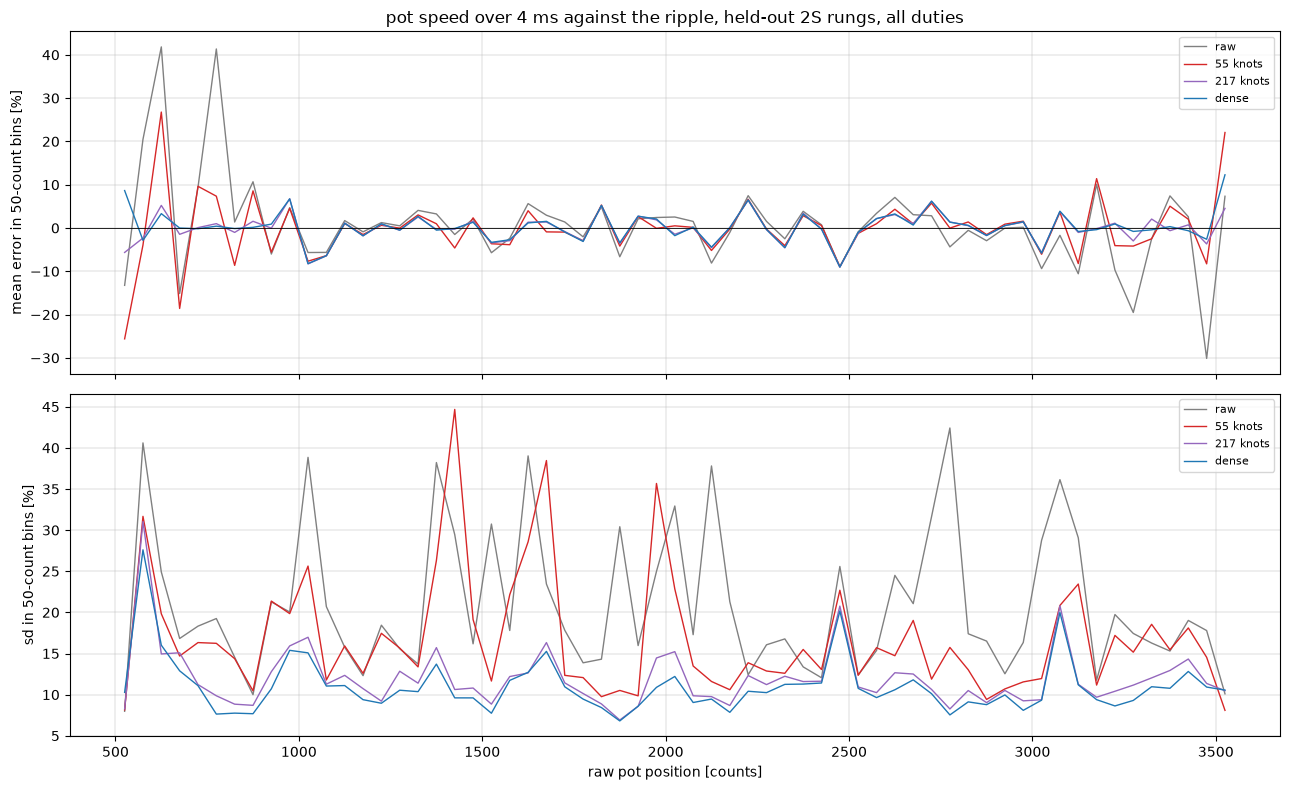

,25-count gain min,max,max over min,"position-locked part of the 4 ms error, rms [%]","the rest, rms [%]"
map,,,,,
raw,0.662,1.585,2.394,8.071,22.670
55 knots,0.744,1.355,1.821,6.408,18.197
217 knots,0.800,1.111,1.390,4.649,11.661
dense,0.802,1.123,1.400,4.513,10.642


In [23]:
h = spd_ev[(spd_ev.set == "2S held out") & (spd_ev.W == 80)].copy()
h["bin"] = (h["at"] // 50) * 50 + 25
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for name, col in zip(ORDER, ["0.5", "tab:red", "tab:purple", "tab:blue"]):
    g = h[h["map"] == name].groupby("bin").err_pct
    axes[0].plot(g.mean().index, g.mean(), color=col, lw=1, label=name)
    axes[1].plot(g.std().index, g.std(), color=col, lw=1, label=name)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("mean error in 50-count bins [%]")
axes[0].set_title("pot speed over 4 ms against the ripple, held-out 2S rungs, all duties")
axes[1].set_ylabel("sd in 50-count bins [%]")
axes[1].set_xlabel("raw pot position [counts]")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

# Flatness of the local gain on the held-out rungs: raw or linearized counts per
# ripple cycle in 25-count windows, pooled over held-out rungs.
rows = []
for name in ORDER:
    g = h[h["map"] == name]
    b25 = (g["at"] // 25)
    m = (g.err_pct.groupby(b25).mean() / 100 + 1)
    rows.append({"map": name, "25-count gain min": m.min(), "max": m.max(), "max over min": m.max() / m.min(),
                 "position-locked part of the 4 ms error, rms [%]": g.err_pct.groupby(b25).transform("mean").std(),
                 "the rest, rms [%]": (g.err_pct - g.err_pct.groupby(b25).transform("mean")).std()})
pd.DataFrame(rows).set_index("map").round(3)

**What you are looking at.** The 4 ms pot speed error on held-out 2S rungs in 50-count bins, the mean
per bin on top and the scatter per bin below, for raw counts, 55 knots, 217 knots and the dense curve.

In mid travel the mean error per 50-count bin is about the same for every map, because the pot's
texture is finer than 50 counts and averages out inside a bin. There linearizing mainly removes the
big excursions near the ends. The scatter panel is where the tables separate. Texture inside a bin
shows up as scatter, the dense and 217-knot curves pull it down to about 8 to 15%, and 55 knots leave
spikes of 25 to 45% wherever a sharp bump sits between two knots (near 1420, 1670 and 1990). The table
under the plot splits the 4 ms error into the part locked to 25-count bins and the rest. The locked
part falls from 8.1% to 6.4% with 55 knots and 4.5% dense. The rest, 11 to 23%, does not go away with
any table. Part of it is texture finer than 25 counts, and most of it is noise. Local gain in 25-count
windows goes from a 2.4x range raw to 1.8x with 55 knots and 1.4x dense.

## 8. The fusion decision

Notebook 08 put the velocity observer on model back-EMF and left the pot supplying position only,
because the pot's speed error was deterministic and 14.5% rms. The question for this notebook is
whether a linearized pot changes that.

Every candidate is evaluated the way the observer would see it, every sample at 20 kHz, on the
held-out 2S rungs, in linearized counts per second, against the ripple over the candidate's own
window. The back-EMF estimate uses a 1 ms boxcar, the one notebook 08 recommends. The pot is differenced
over 4, 8 and 20 ms, whole multiples of 4 ms so the position channel's 250 Hz comb cancels (notebook 08).
A window of $W$ samples also costs $W/2$ samples of lag, 2 ms at 4 ms and 10 ms at 20 ms.

In [24]:
# Every candidate as the observer would see it at 20 kHz, scored against the ripple
# over its own window, in linearized counts per second. Held-out 2S rungs only.
lut_of = {}
for c in caps:
    s = potlut.stitch(chunks([r for r in S2 if r["cap"] != c]), RAW_MIN, RAW_MAX)
    lut_of[c] = (potlut.from_stitch(s, RAW_MIN, RAW_MAX), (s.cum[s.lc] - s.cum[s.fc]) / (s.hi - s.lo))

BOX = 20              # the back-EMF boxcar nb08 recommends, 1 ms

def speeds(r):
    L, c_lin = lut_of[r["cap"]]
    n0 = r["n0"] + M0
    p = r["pos"][n0:]
    cyc = r["cyc"][n0:] * np.sign(r["duty"])
    e_cyc = np.cumsum(np.r_[0, np.diff(r["cyc2"][n0:])]) * np.sign(r["duty"])   # back-EMF angle, same samples
    out = []
    for name, y, W in (("pot raw, 4 ms", p.astype(float), 80), ("pot 55 knots, 4 ms", L.counts(p), 80),
                       ("pot 55 knots, 8 ms", L.counts(p), 160), ("pot 55 knots, 20 ms", L.counts(p), 400),
                       ("back-EMF, 1 ms", e_cyc / c_lin, BOX), ("back-EMF, 4 ms", e_cyc / c_lin, 80)):
        v = (y[W:] - y[:-W]) / (W * DT)
        vr = (cyc[W:] - cyc[:-W]) / (W * DT) / c_lin
        out.append(pd.DataFrame({"est": name, "duty": r["duty"], "at": p[W:], "v_ref": vr, "err": v - vr}))
    return out

fu = pd.concat([d for r in S2 if r["ok"] for d in speeds(r)], ignore_index=True)
fu["speed band"] = pd.cut(fu.duty.abs(), [14, 25, 40, 50, 100], labels=["15-25%", "30-40%", "45-50%", "55-100%"])
fu["region"] = pd.cut(fu["at"], [0, 1100, 1800, 2500, 3200, 4096], labels=["< 1100", "1100-1800", "1800-2500", "2500-3200", "> 3200"])
fu["err_dir"] = fu.err * np.sign(fu.duty)          # positive = reads fast, either direction
by_band = fu.groupby(["speed band", "est"], observed=True).agg(
    speed_cps=("v_ref", lambda v: np.abs(v).mean()), rms_cps=("err", lambda e: np.sqrt(np.mean(e ** 2))),
    bias_cps=("err_dir", "mean"))
by_band["rms_pct"] = by_band.rms_cps / by_band.speed_cps * 100
by_band["bias_pct"] = by_band.bias_cps / by_band.speed_cps * 100
display(by_band.round(1))
print("rms error by travel region, counts per second, all speed bands up to 50% duty")
display(fu[fu.duty.abs() <= 50].groupby(["region", "est"], observed=True).err.apply(
    lambda e: np.sqrt(np.mean(e ** 2))).unstack("est").round(0))
# the back-EMF model above 50% duty, where its Ke was not fitted
hb = fu[fu.est == "back-EMF, 1 ms"].groupby(fu.duty.abs()).apply(
    lambda d: (d.err_dir.mean() / np.abs(d.v_ref).mean()) * 100, include_groups=False)
print("back-EMF bias by duty [%]:", {int(k): round(v, 1) for k, v in hb.items()})

speed_cps  rms_cps  bias_cps  rms_pct  bias_pct
speed band est                                                                 
15-25%     back-EMF, 1 ms          3291.2    106.3      38.9      3.2       1.2
           back-EMF, 4 ms          3291.6     84.1      38.6      2.6       1.2
           pot 55 knots, 20 ms     3292.4    324.1       2.1      9.8       0.1
           pot 55 knots, 4 ms      3291.6    749.7       6.9     22.8       0.2
           pot 55 knots, 8 ms      3292.0    566.3       6.0     17.2       0.2
           pot raw, 4 ms           3291.6    871.9     -33.9     26.5      -1.0
30-40%     back-EMF, 1 ms          6667.0    118.1     -44.6      1.8      -0.7
           back-EMF, 4 ms          6671.2     98.3     -45.1      1.5      -0.7
           pot 55 knots, 20 ms     6688.4    315.1       2.5      4.7       0.0
           pot 55 knots, 4 ms      6671.2   1119.9      -3.9     16.8      -0.1
           pot 55 knots, 8 ms      6676.5    773.4       0.3     11.6       0.0
           pot raw, 4 ms           6671.2   1430.4     -97.1     21.4      -1.5
45-50%     back-EMF, 1 ms          9229.5    185.0      81.7      2.0       0.9
           back-EMF, 4 ms          9238.2    141.1      81.1      1.5       0.9
           pot 55 knots, 20 ms     9271.2    322.9      -2.4      3.5      -0.0
           pot 55 knots, 4 ms      9238.2   1299.9       5.8     14.1       0.1
           pot 55 knots, 8 ms      9248.2    820.1       3.3      8.9       0.0
           pot raw, 4 ms           9238.2   1788.5    -130.1     19.4      -1.4
55-100%    back-EMF, 1 ms         13628.9   2787.5    2355.0     20.5      17.3
           back-EMF, 4 ms         13633.4   2776.5    2352.6     20.4      17.3
           pot 55 knots, 20 ms    13637.3    304.7      -7.6      2.2      -0.1
           pot 55 knots, 4 ms     13633.4   1548.6     -10.3     11.4      -0.1
           pot 55 knots, 8 ms     13638.2    781.8     -10.0      5.7      -0.1
           pot raw, 4 ms          13633.4   2388.1    -310.6     17.5      -2.3

rms error by travel region, counts per second, all speed bands up to 50% duty


est,"back-EMF, 1 ms","back-EMF, 4 ms","pot 55 knots, 20 ms","pot 55 knots, 4 ms","pot 55 knots, 8 ms","pot raw, 4 ms"
region,,,,,,
< 1100,167.0,138.0,286.0,910.0,615.0,1176.0
1100-1800,109.0,87.0,410.0,1188.0,869.0,1295.0
1800-2500,108.0,87.0,292.0,871.0,585.0,1153.0
2500-3200,121.0,88.0,251.0,748.0,508.0,1190.0
> 3200,152.0,134.0,206.0,762.0,473.0,919.0


back-EMF bias by duty [%]: {15: 1.9, 20: 1.1, 25: 0.5, 30: -0.0, 35: -0.8, 40: -1.2, 45: 0.3, 50: 1.5, 55: 4.8, 60: 6.2, 65: 9.0, 70: 12.7, 75: 15.2, 80: 17.5, 85: 19.3, 90: 21.2, 95: 25.0, 100: 28.4}


Read by speed band. From 15 to 50% duty, back-EMF over 1 ms is off by 1.8 to 3.2% rms, with a bias
of about 1%. The 55-knot pot over 4 ms is off by 14 to 23%, over 20 ms by 3.5 to 10%. So where both
exist, back-EMF wins by about nine times at the same 4 ms window, and even the 20 ms pot,
with five times the lag, is two to three times worse than 1 ms of back-EMF. By region the story is the same,
the back-EMF error sits at 110 to 170 counts per second everywhere and the pot's at 750 to 1200.

Above 50% duty it flips. The back-EMF model, with $K_e$ fitted from 15 to 50%, reads 5% fast at 55%
duty and 28% fast at 100%. That is the speed-driven excess notebook 08 found on the SG90 (11% at full
duty there) and it is bigger on this motor. The pot does not care about duty, 2.2% at 20 ms and 11%
at 4 ms.

In [25]:
# At rest the back-EMF path does not exist (duty 0, window_valid 0), so the pot is
# the only speed there is. Its noise over the baseline, after the 200 ms ring-down.
rows = []
for cap, df, meta in frames(ds, "grid"):
    p = LUT.counts(df[df.seg == 0].pos.to_numpy()[4000:])
    for W in (20, 80, 160, 400):
        rows.append({"cap": cap, "W": W, "sd": np.std((p[W:] - p[:-W]) / (W * DT))})
rest = pd.DataFrame(rows).groupby("W").sd.agg(["mean", "min", "max"])
rest.index = [f"{w * DT * 1e3:g} ms" for w in rest.index]
print("pot speed noise at rest, linearized counts per second (the true speed is zero)")
display(rest.round(0))

# Where the back-EMF path switches on: window_valid against duty over the breakaway ladder.
bw = []
for cap, df, meta in frames(ds, "breakaway"):
    for seg, g in df[df.seg > 0].groupby("seg"):
        bw.append({"duty": round(abs(g.cmd_duty_q15.iloc[0]) * 100 / Q15), "valid": g.window_valid.mean()})
bw = pd.DataFrame(bw).groupby("duty").valid.mean()
print("fraction of samples with window_valid, breakaway ladder:", {int(k): round(v, 2) for k, v in bw.items() if 10 <= k <= 18})

pot speed noise at rest, linearized counts per second (the true speed is zero)


,mean,min,max
1 ms,1502.0,1193.0,1751.0
4 ms,177.0,135.0,216.0
8 ms,88.0,67.0,108.0
20 ms,35.0,27.0,43.0


fraction of samples with window_valid, breakaway ladder: {10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0}


At rest the back-EMF path does not exist. Duty is zero, `window_valid` is clear, and there is no
winding current to read. The breakaway ladder shows the flag switching on between 13 and 14% duty, so
below that the pot is the only speed there is. At rest its noise in linearized counts per second is
about 180 over 4 ms and 35 over 20 ms.

The weights. If two estimates of the same speed have independent errors with variances
$\sigma_{pot}^2$ and $\sigma_{bemf}^2$, the best blend gives the pot a weight

$$w_{pot} = \frac{\sigma_{bemf}^2}{\sigma_{pot}^2 + \sigma_{bemf}^2}$$

I use the total measured error here, bias and scatter together, since neither is zero mean.

In [26]:
# Inverse-variance weight of the pot against the 1 ms back-EMF, per speed band, from
# the measured total error (bias and scatter together, since neither is zero mean).
tot = fu.groupby(["speed band", "est"], observed=True).err.apply(lambda e: np.sqrt(np.mean(e ** 2))).unstack("est")
rec = pd.DataFrame({"speed [counts/s]": by_band.xs("back-EMF, 1 ms", level="est").speed_cps,
                    "back-EMF 1 ms, rms [counts/s]": tot["back-EMF, 1 ms"]})
for est in ("pot raw, 4 ms", "pot 55 knots, 4 ms", "pot 55 knots, 20 ms"):
    rec[f"{est}, rms"] = tot[est]
    rec[f"w_pot, {est}"] = tot["back-EMF, 1 ms"] ** 2 / (tot[est] ** 2 + tot["back-EMF, 1 ms"] ** 2)
display(rec.round(3))
# the speed at which the pot's error would match the back-EMF's, pot error modelled
# as rest noise plus a fraction of speed
g55 = (by_band.xs("pot 55 knots, 4 ms", level="est").rms_pct / 100).median()
gb = (tot["back-EMF, 1 ms"] / rec["speed [counts/s]"]).median()
n4 = rest.loc["4 ms", "mean"]
print(f"pot 55 knots, 4 ms: rest noise {n4:.0f} counts/s plus {g55 * 100:.1f}% of speed; "
      f"back-EMF 1 ms: {gb * 100:.1f}% of speed where it exists")

,speed [counts/s],"back-EMF 1 ms, rms [counts/s]","pot raw, 4 ms, rms","w_pot, pot raw, 4 ms","pot 55 knots, 4 ms, rms","w_pot, pot 55 knots, 4 ms","pot 55 knots, 20 ms, rms","w_pot, pot 55 knots, 20 ms"
speed band,,,,,,,,
15-25%,3291.238,106.254,871.928,0.015,749.673,0.020,324.104,0.097
30-40%,6666.992,118.103,1430.374,0.007,1119.887,0.011,315.096,0.123
45-50%,9229.483,184.974,1788.531,0.011,1299.897,0.020,322.905,0.247
55-100%,13628.911,2787.508,2388.114,0.577,1548.568,0.764,304.654,0.988


pot 55 knots, 4 ms: rest noise 177 counts/s plus 15.4% of speed; back-EMF 1 ms: 2.6% of speed where it exists


**The recommendation, for notebook 08 and the observer.**

1. **Where back-EMF is valid and the duty is at most 50%, the pot stays position only.** Its weight
   against 1 ms back-EMF is 0.007 to 0.020 at 4 ms, linearized or not. Linearization moves it by
   less than a factor of two and it stays negligible. At 20 ms it would reach 0.10 to 0.25, but at
   10 ms of lag, which a velocity loop would feel, and back-EMF over 4 ms is still two to four
   times better.
2. **Below the back-EMF validity floor (`window_valid` clear, under about 14% duty on 2S) and at rest,
   the pot is the velocity source**, differenced over a whole multiple of 4 ms on linearized counts.
   Its error there is noise-dominated (about 180 counts per second over 4 ms at rest, 35 over 20 ms)
   plus about 15% of speed from texture at 4 ms. The linearization matters most here, because this is
   where the pot's speed is the only one there is.
3. **Above 50% duty the back-EMF model as it stands should not be trusted for speed.** It reads 5 to
   28% fast. Until the high-speed term is fixed (notebook 08's open item), a 20 ms linearized pot
   derivative is the better estimate up there, about 2% rms. Weight on it from these numbers, 0.76
   at 4 ms and 0.99 at 20 ms.

So the switch is by availability and by duty, not a fixed blend. In observer terms, the back-EMF
enters as a velocity measurement whenever `window_valid` is set and $|D| \le 50\%$, and the pot's
velocity innovation only has weight outside that. A finer table (217 knots) would bring the 4 ms pot
from about 19% to 13% and does not change any of these three answers.

## 9. What changes downstream

Every plant constant with a pot count in its unit was fitted in raw counts. In linearized counts the
settled windows those fits average over read slightly differently, so the constants move. I re-run
the fits of the bringup `plant.py` on the same 2S session grid twice, once in raw counts and once
through the 55-knot table, with no recapture. $K_e$ here is `ke_vpc`, back-EMF in tap counts per pot
count per second. $f_c$ and $f_v$ are the Coulomb and viscous current terms against pot speed.
$\sigma_\theta$ is the rest noise of position. The last row is the speed-per-duty slope the capture
pilot uses to size its windows.

In [27]:
# plant.py's definitions (bringup captures/mg90/plant.py), run twice over the same
# 2S session grid: once in raw counts, once in linearized counts.
r_vpc = R_OHM * board.a_per_count / board.v_term_per_count     # ohm in tap counts per current count
def plant(fn):
    ke_rows, fr_rows, sig, vss = [], [], [], []
    for cap, df, meta in frames(ds, "grid"):
        base = df[df.seg == 0]
        bias = base.current_raw.mean()
        sig.append(np.std(fn(base.pos.to_numpy()[4000:])))
        for seg, g in df[df.seg > 0].groupby("seg"):
            d = g.cmd_duty_q15.iloc[0] / Q15
            pct = abs(d) * 100
            n = len(g)
            tail = slice(int(n * 0.6), n)                              # plant.py SETTLED = 0.4
            if pct < 15 or g.window_valid.to_numpy()[tail].mean() <= 0.95:
                continue
            t = np.arange(n) * DT
            w = np.polyfit(t[tail], fn(g.pos.to_numpy()[tail]), 1)[0]  # pot slope, counts per second
            i = np.sign(d) * (g.current_raw.to_numpy()[tail] - bias).mean()
            y = abs(d) * (g.vmotor_a.to_numpy()[tail] - g.vmotor_b.to_numpy()[tail]).astype(float).mean()
            if 20 <= pct <= 60:
                ke_rows.append((w, y - r_vpc * i))
                fr_rows.append((np.sign(d), w, i))
            if 10 <= pct <= 50:
                vss.append((np.sign(d), pct, abs(w) / 1e3))
    w, e = np.array(ke_rows).T
    out = {"ke_vpc [tap counts per count/s]": np.polyfit(w, e, 1)[0],
           "sigma_theta [counts]": np.mean(sig)}
    fr = np.array(fr_rows)
    for s, lab in ((1, "fwd"), (-1, "rev")):
        m = fr[:, 0] == s
        fv, fc = np.polyfit(fr[m, 1], fr[m, 2], 1)
        out[f"fc {lab} [current counts]"] = abs(fc)
        out[f"fv {lab} [current counts per count/s]"] = fv
    v = np.array(vss)
    m = v[:, 0] == -1                                                 # the pilot sizes windows on reverse
    out["v_ss slope, rev [counts/ms per % duty]"] = np.polyfit(v[m, 1], v[m, 2], 1)[0]
    return out

raw_p, lin_p = plant(lambda p: p.astype(float)), plant(LUT.counts)
dn = pd.DataFrame({"raw counts": raw_p, "linearized counts": lin_p})
dn["change [%]"] = (dn["linearized counts"] / dn["raw counts"] - 1) * 100
display(dn.round(5))

lim = pd.DataFrame({"raw": [SOFT[0], GUARD[0], GUARD[1], SOFT[1]]},
                   index=["soft low", "guard low", "guard high", "soft high"])
lim["linearized"] = LUT.counts(lim["raw"].to_numpy()).round(1)
lim["moves by [counts]"] = lim["linearized"] - lim["raw"]
display(lim)

_, s55 = sensitivity(x, LUT.counts(x), 67)
_, sraw = sensitivity(x, lin, 67)
print(f"position-loop gain across travel, 67-count windows: raw counts {sraw.min():.2f} .. {sraw.max():.2f} x nominal, "
      f"55-knot counts {(sraw / s55).min():.3f} .. {(sraw / s55).max():.3f} x nominal")

,raw counts,linearized counts,change [%]
ke_vpc [tap counts per count/s],0.14717,0.14152,-3.84387
sigma_theta [counts],1.19357,1.13601,-4.82277
fc fwd [current counts],59.17821,59.92966,1.26981
fv fwd [current counts per count/s],0.00452,0.00437,-3.36159
fc rev [current counts],45.96516,46.39807,0.94183
fv rev [current counts per count/s],0.00635,0.00590,-6.98650
"v_ss slope, rev [counts/ms per % duty]",0.20010,0.21320,6.54298


,raw,linearized,moves by [counts]
soft low,432,432.0,0.0
guard low,532,532.8,0.8
guard high,3526,3529.2,3.2
soft high,3626,3626.0,0.0


position-loop gain across travel, 67-count windows: raw counts 0.71 .. 1.35 x nominal, 55-knot counts 0.873 .. 1.157 x nominal


What moves, and why.

- **`ke_vpc` drops 3.8% and $f_v$ drops 3.4% forward and 7.0% reverse.** Both are fitted against pot
  speed over the last 40% of a rung, and those settled windows happen to sit on stretches where the
  pot reads a little slow (reverse rungs finish low on travel, forward rungs high). Linearized, the
  same speed reads a few percent higher, so the constants per count/s come out lower. $f_c$ is an intercept and moves about 1%.
- **The speed-per-duty slope rises 6.5%**, the same effect seen the other way round, since the pilot
  fits it on reverse rungs.
- **$\sigma_\theta$ drops 4.8%**, because the rest position happens to sit where the pot reads a
  little fast, so its noise shrinks in true counts.
- **The guards move by under 4 counts** and the soft limits by nothing, because 432 and 3626 are in the
  inset the table leaves at identity. They stay valid as they are.
- **The position loop's gain across travel**, 0.71 to 1.35 times nominal in raw counts at the scale of
  one knot interval, becomes 0.87 to 1.16 times in 55-knot counts.

Every one of those moves is a few percent, well inside the brackets the gain synthesis already
carries for this servo, but they are systematic. When the firmware applies the table, the plant
constants for `osc ident synth` should be refit in linearized counts by running the same fits through
the table, which this cell already does.

## 10. After the firmware applies the table

This section is a placeholder until the firmware work lands. The confirmation capture is the same 2S
merged session, five captures, with the table written and saved and TEL still streaming raw `pos`.
The firmware's linearized position is not in the capture mask today. It would need adding as a
channel, or reconstructing offline from raw `pos` and the stored table, which is what this notebook
does now.

What to compare, with the pass line for each.

- The table read back from the servo against the JSON here, knot for knot.
- The linearized position the firmware reports against `potlut.PotLut.counts` on the same raw
  samples, to the rounding of the fixed-point math (within one count).
- Held-out position error on the new captures against section 7 (4.6 counts rms).
- Pot speed error at 4 ms against section 7 (19%).
- The plant refit through the firmware's own counts against section 9's linearized column.
- A position-hold and step check across travel. The step response should not change with position
  the way it does today (loop gain 0.71 to 1.35 times nominal across travel in raw counts).

## Caveats

- **One servo, one board.** Everything here describes mg90-a on the bodged board D. The table is a
  property of this one pot and has to be measured per servo.
- **The ends of the table rest on route 1 alone.** Proof rule 1 is met from 1100 to 3050 and not met
  at the two ends (section 3).
- **The covered range is 541 to 3526.** Outside it the table is identity by construction. That
  includes both soft limits, so any goal between a soft limit and the covered end is uncorrected.
- **R is pinned** from a different fit, with an open 7% gap between two routes to it. It enters only
  route 2 and moves the shape by under half a count in the middle.
- **The back-EMF model is only fitted to 50% duty.** Its 5 to 28% over-read above that is taken as
  measured, not explained.
- **The newer USB session finished recording while this notebook was being built.** The run
  committed here uses all five of its captures.
- **Degrees are nowhere.** The gear ratio of this servo is not known yet. Nothing in the table needs
  it, and everything is in counts and ripple cycles.

## Open discrepancies

**1. Route 2 over-reads at the ends of travel.** Up to 6% in density over the first few hundred counts
of every rung, where only spin-up covers the pot.
Candidates: (a) an error in $R\,i$ during the high spin-up current, (b) the inductive term I leave out,
(c) the crest current under-reading while the current is changing (notebook 00's island-cap charge
sharing).
What separates them: capture rungs that pass through the ends at speed, by starting a 15% rung beyond
the guard (a short seek to the soft limit, then the rung, 15% has the shortest spin-up at about 80
counts). If route 2 agrees at the ends when the shaft is at speed there, it was the spin-up and route 1
is confirmed at the ends. If it still disagrees at speed, one of the routes has a position-dependent
error at the ends.

**2. Forward and reverse differ by a position-locked bump near raw 2500.** Up to 11 counts, both routes,
independent of drive current.
Candidates: (a) the wiper contacts the track differently each way over a patch of texture, (b) tooth
transmission error that differs between the two flanks of one mesh.
What separates them: (a) is fixed to the pot track and (b) to the gear phase. Remove the output gear
from the pot's D-key, rotate it by a known number of teeth and refit it, then recapture. A pot feature
stays at the same raw count and a gear feature moves by the rotation. Without taking it apart, a test
at a slower duty with a mass on the horn reverses the load on the output and would move (b) but not (a).

**3. The classic 2S grid disagrees with the session by 3.3 counts rms.** Both are this servo, a day apart.
Candidates: (a) the pot or the train changed overnight (the rig was reassembled), (b) the older firmware
and capture timing, (c) scatter I have not captured enough of.
What separates them: a new classic-style grid captured today, right after a session. If it matches the
session, (a) and (c) are out.

**4. The USB tables sit up to 8 to 15 counts off the 2S table in a broad hump through the middle.**
Candidates: (a) a real supply effect on the pot reading, for example the pot's 3V3 reference or the
ground moving with the motor current, which is drawn from a softer rail on USB, (b) a small density
difference near the rung starts where the lower USB current spins up differently, spread by the
anchoring, (c) the servo changing between the two sessions, which were recorded hours apart.
What separates them: (a) predicts the offset scales with motor current, so a USB grid at matched
current to a 2S grid (lower duty on 2S) should close it. (b) disappears in the at-speed end capture of
item 1. (c) needs a 2S session recorded straight after a USB one.

**5. The ADC's wide codes at 1023 and 3072.** Measured, not a discrepancy. They are dead bands of about 5
and 8 codes that no table can split. Whether a different ADC clock or sample time narrows them is a
converter question for the firmware.

## Where this goes next

The table is in the bringup repo as JSON and the port that built it is `oscnb.potlut`. The next step is
a firmware plan for Aaron's review, the one sketched in the project notes. Apply the table once per pot
sample at the sensor boundary, no divide (a reciprocal of the knot spacing precomputed on write), validate
it on write, all-zero means identity so a servo without a table is unchanged, and TEL keeps raw `pos`.
Three findings here feed that plan.

- Anchor the table on a coverage threshold, not on the extreme samples, as this notebook does. Otherwise
  one stray rung moves every knot.
- 55 knots are enough for position. For the pot to be a useful speed source below the back-EMF floor, a
  finer table would help, and 217 knots is 434 bytes.
- The slip check gets three times more sensitive on linearized counts.

Section 10 is waiting for the capture that confirms it all on the servo.